**Table of contents**<a id='toc0_'></a>    
- [Data Mining Lab 2 - Phase 2](#toc1_)    
  - [Before Starting](#toc1_1_)    
  - [Introduction](#toc1_2_)    
  - [**1. Data Preparation**](#toc1_3_)    
  - [**1.1 Load data**](#toc1_4_)    
    - [**1.2 Save data**](#toc1_4_1_)    
  - [**2. Large Language Models (LLMs)**](#toc1_5_)    
    - [Open-Source vs. Proprietary LLMs](#toc1_5_1_)    
    - [Why Use Code (API) for Data Mining?](#toc1_5_2_)    
    - [The Gemini API](#toc1_5_3_)    
    - [Interacting with the Gemini API](#toc1_5_4_)    
    - [**2.1 Text Prompting**](#toc1_5_5_)    
        - [**>>> Exercise 1 (Take home):**](#toc1_5_5_1_1_)    
    - [**2.2 Structured Output**](#toc1_5_6_)    
        - [**>>> Exercise 2 (Take home):**](#toc1_5_6_1_1_)    
    - [**2.3 Information Extraction and Grounding:**](#toc1_5_7_)    
      - [**`langextract`: A Library for Grounded Extraction**](#toc1_5_7_1_)    
        - [**2.3.1 Using PDF Documents:**](#toc1_5_7_1_1_)    
        - [**>>> Bonus Exercise 3 (Take home):**](#toc1_5_7_1_2_)    
    - [**2.4 Generating LLM Embeddings:**](#toc1_5_8_)    
        - [**>>> Exercise 4 (Take home):**](#toc1_5_8_1_1_)    
    - [**2.5 Retrieval-Augmented Generation (RAG)**](#toc1_5_9_)    
        - [**Actual answer in the URL:**](#toc1_5_9_1_1_)    
        - [**Content in the URL that might get into the generated answer because of similar semantic meaning:**](#toc1_5_9_1_2_)    
        - [**>>> Bonus Exercise 5 (Take home):**](#toc1_5_9_1_3_)    
    - [**2.6 Few-Shot Prompting Classification:**](#toc1_5_10_)    
        - [**>>> Exercise 6 (Take home):**](#toc1_5_10_1_1_)    
        - [**>>> Exercise 7 (Take home):**](#toc1_5_10_1_2_)    
    - [**2.7 Extra LLM Related Materials:**](#toc1_5_11_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Data Mining Lab 2 - Phase 2](#toc0_)
In this lab's phase 2 session we will focus on exploring some basic LLMs' applications with data.


## <a id='toc1_1_'></a>[Before Starting](#toc0_)

**Make sure you have installed all the required libraries and you have the environment ready to run this lab.**
    

---
## <a id='toc1_2_'></a>[Introduction](#toc0_)

**Dataset:** [SemEval 2017 Task](https://competitions.codalab.org/competitions/16380)

**Task:** Classify text data into 4 different emotions using word embeddings and other deep information retrieval approaches.

![pic0.png](./pics/pic0.png)

---
## <a id='toc1_3_'></a>[**1. Data Preparation**](#toc0_)

---
## <a id='toc1_4_'></a>[**1.1 Load data**](#toc0_)

We start by loading the csv files into a single pandas dataframe for training and one for testing.

In [170]:
import pandas as pd

### training data
anger_train = pd.read_csv("data/semeval/train/anger-ratings-0to1.train.txt",
                         sep="\t", header=None,names=["id", "text", "emotion", "intensity"])
sadness_train = pd.read_csv("data/semeval/train/sadness-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_train = pd.read_csv("data/semeval/train/fear-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_train = pd.read_csv("data/semeval/train/joy-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

In [171]:
# combine 4 sub-dataset
train_df = pd.concat([anger_train, fear_train, joy_train, sadness_train], ignore_index=True)

In [172]:
### testing data
anger_test = pd.read_csv("data/semeval/dev/anger-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
sadness_test = pd.read_csv("data/semeval/dev/sadness-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_test = pd.read_csv("data/semeval/dev/fear-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_test = pd.read_csv("data/semeval/dev/joy-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

# combine 4 sub-dataset
test_df = pd.concat([anger_test, fear_test, joy_test, sadness_test], ignore_index=True)
# print(train_df.to_string())

In [173]:
# shuffle dataset
train_df = train_df.sample(frac=1)
test_df = test_df.sample(frac=1)

In [174]:
print("Shape of Training df: ", train_df.shape)
print("Shape of Testing df: ", test_df.shape)

Shape of Training df:  (3613, 4)
Shape of Testing df:  (347, 4)


---
### <a id='toc1_4_1_'></a>[**1.2 Save data**](#toc0_)

In [175]:
# save to pickle file
train_df.to_pickle("./data/train_df.pkl") 
test_df.to_pickle("./data/test_df.pkl")

In [176]:
import pandas as pd

# load a pickle file
train_df = pd.read_pickle("./data/train_df.pkl")
test_df = pd.read_pickle("./data/test_df.pkl")

For more information: https://reurl.cc/0Dzqx

---
## <a id='toc1_5_'></a>[**2. Large Language Models (LLMs)**](#toc0_)

Before we start we strongly suggest that you watch the following video explanations so you can understand the concepts that we are gonna discuss about LLMs: 

1. [How Large Language Models Work](https://www.youtube.com/watch?v=5sLYAQS9sWQ)
2. [Large Language Models explained briefly](https://www.youtube.com/watch?v=LPZh9BOjkQs)
3. [What is Prompt Tuning?](https://www.youtube.com/watch?v=yu27PWzJI_Y)
4. [Why Large Language Models Hallucinate](https://www.youtube.com/watch?v=cfqtFvWOfg0)
5. [What are LLM Embeddings?](https://www.youtube.com/watch?v=UShw_1NbpCw&t=182s)
6. [What is Retrieval-Augmented Generation (RAG)?](https://www.youtube.com/watch?v=T-D1OfcDW1M)
7. [RAG vs Fine-Tuning vs Prompt Engineering: Optimizing AI Models](https://www.youtube.com/watch?v=zYGDpG-pTho)
8. [Discover Few-Shot Prompting | Google AI Essentials](https://www.youtube.com/watch?v=9qdgEBVkWR4)
9. [What is Zero-Shot Learning?](https://www.youtube.com/watch?v=pVpr4GYLzAo)
10. [Zero-shot, One-shot and Few-shot Prompting Explained | Prompt Engineering 101](https://www.youtube.com/watch?v=sW5xoicq5TY)

`These videos can help you get a better grasp on the core concepts of LLMs if you were not familiar before.`

**So now let's start with the main content of Lab 2 Phase 2.**

Large Language Models (LLMs) are AI systems trained on vast amounts of text to understand and generate human language for tasks like summarization and translation.

### <a id='toc1_5_1_'></a>[Open-Source vs. Proprietary LLMs](#toc0_)
*   **Open-Source Models** (e.g., Llama, Gemma) are customizable and cost-effective but require technical skill to manage and may be less powerful.
*   **Proprietary Models** (e.g., Gemini, ChatGPT) offer top performance and ease of use but are more costly and less flexible.

For students interested in running models locally, the optional notebook `DM2025-Lab2-Optional-Ollama.ipynb` explores using Ollama ([Ollama GitHub Link](https://github.com/ollama/ollama)). It needs a capable GPU to run models (**at least 4GB VRAM**).

You can explore the variety of models available through Ollama here:

![pic10.png](./pics/pic10.png)

### <a id='toc1_5_2_'></a>[Why Use Code (API) for Data Mining?](#toc0_)

For data analysis, accessing LLMs programmatically is superior to using web chatbots because it allows for:
*   **Automation:** Easily process entire datasets with loops.
*   **Structured Output:** Receive data in usable formats like **JSON**, ready for analysis in tools like pandas.
*   **Reproducibility:** Ensure consistent results by setting fixed parameters.
*   **Privacy:** Maintain data security, especially when running models locally.

For the main exercises in this lab, we will use **the Gemini API**. This approach offers several advantages over running local open-source models, such as access to state-of-the-art model performance without needing specialized hardware. While the API has usage limits (rate limits and token quotas), it provides a generous **free tier** that is more than sufficient for our exercises.

![pic13.png](./pics/pic13.png)

![pic14.png](./pics/pic14.png)

### <a id='toc1_5_3_'></a>[The Gemini API](#toc0_)

We will primarily use the **Gemini 2.5 Flash-Lite** (`gemini-2.5-flash-lite`) model. As shown in the rate limit table, this model is optimized for high-frequency tasks and offers a high request-per-day limit of 1,000, making it ideal for completing the lab exercises without interruption.

Students are encouraged to explore other models available through the API but should remain mindful of their respective usage limits. For instance:
*   **Gemini 2.5 Pro** is a more powerful model but has a lower daily request limit of 100.
*   The **Gemma 3** model available via the API offers an impressive 14,400 requests per day, providing another excellent alternative for experimentation.

Please be aware of your usage limits as you work through the exercises to ensure you do not get rate-limited.

[Gemini Documentation](https://ai.google.dev/gemini-api/docs)

[Gemini Rate Limits](https://ai.google.dev/gemini-api/docs/rate-limits)

[Description of Gemini Models](https://ai.google.dev/gemini-api/docs/models)

---

### <a id='toc1_5_4_'></a>[Interacting with the Gemini API](#toc0_)

The code cell below contains the primary function, `prompt_gemini`, that we will use throughout this lab to communicate with the Gemini API. It's designed to be a flexible wrapper that handles the details of sending a request and receiving a response.

Before you run the exercises, here are the key things you need to understand in this setup:

*   **API Key Configuration**: The script loads your API key from a `.env` file located in the `./config/` directory. **You must create this file and add your API key** like this: `GOOGLE_API_KEY='YOUR_API_KEY_HERE'`. This is a security best practice to keep your credentials out of the code.

*   **Global Settings**: At the top of the script, you can find and modify several important defaults:
    *   `MODEL_NAME`: We've set this to `"gemini-2.5-flash-lite"`, but you can easily switch to other models like `"gemini-2.5-pro"` to experiment.
    *   `SYSTEM_INSTRUCTION`: This sets the model's default behavior or persona (e.g., "You are a helpful assistant"). You can customize this for different tasks.
    *   `SAFETY_SETTINGS`: For our academic exercises, these are turned off to prevent interference. In real-world applications, you would configure these carefully.

*   **The `prompt_gemini` function**: This is the main tool you will use. Here are its most important parameters:
    *   `input_prompt`: The list of contents (text, images, etc.) you want to send to the model.
    *   `temperature`: Controls the randomness of the output. `0.0` makes the output deterministic and less creative, while a higher value (e.g., `0.7`) makes it more varied.
    *   `schema`: A powerful feature that allows you to specify a JSON format for the model's output. This is extremely useful for structured data extraction.
    *   `with_tokens_info`: If set to `True`, the function will also return the number of input and output tokens used, which is helpful for monitoring your usage against the free tier limits.

In the following exercises, you will call this function with different prompts and configurations to solve various tasks.

If needed, you can also check some tutorials on how a python function works: [Python Functions Tutorial](https://realpython.com/defining-your-own-python-function/)

In [177]:
import os
from dotenv import load_dotenv
from google import genai
from google.genai import types

env_path = "./config/.env"
load_dotenv(dotenv_path=env_path)

# System instruction that can dictate how the model behaves in the output, can be customized as needed
SYSTEM_INSTRUCTION = (
        "You are a helpful assistant"
    )

# Max amount of tokens that the model can output, the Gemini 2.5 Models have this maximum amount
# For other models need to check their documentation 
MAX_OUTPUT_TOKENS = 65535
MODEL_NAME = "gemini-2.5-flash-lite" # Other models: "gemini-2.5-pro", "gemini-2.5-flash"; Check different max output tokens: "gemini-2.0-flash" , "gemini-2.0-flash-lite" 

# We disable the safety settings, as no moderation is needed in our tasks
SAFETY_SETTINGS = [
    types.SafetySetting(
        category="HARM_CATEGORY_HATE_SPEECH", threshold="OFF"),
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT", threshold="OFF"),
    types.SafetySetting(
        category="HARM_CATEGORY_SEXUALLY_EXPLICIT", threshold="OFF"),
    types.SafetySetting(
        category="HARM_CATEGORY_HARASSMENT", threshold="OFF")
]

#IMPORTANT: The script loads your API key from a `.env` file located in the `./config/` directory. 
# You must create this file and add your API key like this: `GOOGLE_API_KEY='YOUR_API_KEY_HERE'`

# We input the API Key to be able to use the Gemini models
api_key = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = api_key
client = genai.Client(api_key=api_key)

# We also set LangExtract to use the API key as well:
if 'GEMINI_API_KEY' not in os.environ:
    os.environ['GEMINI_API_KEY'] = api_key

def prompt_gemini(
        input_prompt: list,
        schema = None,
        temperature: float = 0.0,
        system_instruction: str = SYSTEM_INSTRUCTION,
        max_output_tokens: int = MAX_OUTPUT_TOKENS,
        client: genai.Client = client,
        model_name: str = MODEL_NAME,
        new_config: types.GenerateContentConfig = None,
        with_tools: bool = False,
        with_parts: bool = False,
        with_tokens_info: bool = False
    ):
        try:
            # If we need a JSON schema we set up the following
            if schema:
                generate_content_config = types.GenerateContentConfig(
                    temperature=temperature,
                    system_instruction=system_instruction,
                    max_output_tokens=max_output_tokens,
                    response_modalities=["TEXT"],
                    response_mime_type="application/json",
                    response_schema=schema,
                    safety_settings=SAFETY_SETTINGS
                )
            # If there is no need we leave it unstructured
            else:
                generate_content_config = types.GenerateContentConfig(
                    temperature=temperature,
                    system_instruction=system_instruction,
                    max_output_tokens=max_output_tokens,
                    response_modalities=["TEXT"],
                    safety_settings=SAFETY_SETTINGS
                )
            
            # We add a different custom configuration if we need it
            if new_config:
                generate_content_config = new_config
            
            # For some tasks we need a more specific way to add the contents when prompting the model
            # So we need custom parts for it sometimes from the "types" objects
            if with_parts:
                response = client.models.generate_content(
                    model=model_name,
                    contents=types.Content(parts=input_prompt),
                    config=generate_content_config,
                )
            # In the simplest form the contents can be expressed as a list [] of simple objects like str and Pillow images
            else:
                response = client.models.generate_content(
                    model=model_name,
                    contents=input_prompt,
                    config=generate_content_config,
                )

            if with_tools:
                # print(response)
                # Include raw response when function calling
                completion = response
                if with_tokens_info:
                    log = {
                        "model": model_name,
                        "input_tokens": response.usage_metadata.prompt_token_count,
                        "output_tokens": response.usage_metadata.candidates_token_count,
                    }
                    return completion, log
                return completion
            else:
                completion = response.text
                if with_tokens_info:
                    log = {
                        "model": model_name,
                        "input_tokens": response.usage_metadata.prompt_token_count,
                        "output_tokens": response.usage_metadata.candidates_token_count,
                    }
                    # Return the text response and logs (if selected)
                    return completion, log
                return completion
        except Exception as e:
             print(f"Error occurred when generating response, error: {e}")
             return None

---
### <a id='toc1_5_5_'></a>[**2.1 Text Prompting**](#toc0_)

In the same way as with ChatGPT we can use the Gemini models to ask about anything. Here we are going to ask a question requesting the response to be in markdown format, this is to make it have a better display afterwards.

For more information visit:
[Gemini's Text Generation Documentation](https://ai.google.dev/gemini-api/docs/text-generation)

In [178]:
input_prompt = ["What is Data Mining?"]
text_response, logs = prompt_gemini(input_prompt = input_prompt, with_tokens_info = True)
print(text_response)

Data mining is the process of **discovering patterns, insights, and knowledge from large datasets**. It's essentially about extracting valuable information that isn't immediately obvious from raw data. Think of it as sifting through a mountain of information to find hidden gems.

Here's a breakdown of what that means:

**Key Concepts:**

*   **Large Datasets:** Data mining is typically applied to datasets that are too large and complex for manual analysis. This can include customer transaction records, website logs, sensor data, social media feeds, scientific experiment results, and much more.
*   **Patterns and Insights:** The goal is to identify recurring trends, correlations, anomalies, and relationships within the data. These patterns can reveal underlying structures, predict future behavior, or explain observed phenomena.
*   **Knowledge Discovery:** The ultimate aim is to transform raw data into actionable knowledge that can be used for decision-making, problem-solving, and strat

We can also check the logs of the usage with our model that we defined in our previous function. We can observe the model we used, how many tokens where in the prompt in the input, and the output text response tokens of our model.

In [179]:
print(logs)

{'model': 'gemini-2.5-flash-lite', 'input_tokens': 12, 'output_tokens': 911}


**We can use the IPython library to make the response look better:**

In [180]:
from IPython.display import display, Markdown
display(Markdown(text_response))

Data mining is the process of **discovering patterns, insights, and knowledge from large datasets**. It's essentially about extracting valuable information that isn't immediately obvious from raw data. Think of it as sifting through a mountain of information to find hidden gems.

Here's a breakdown of what that means:

**Key Concepts:**

*   **Large Datasets:** Data mining is typically applied to datasets that are too large and complex for manual analysis. This can include customer transaction records, website logs, sensor data, social media feeds, scientific experiment results, and much more.
*   **Patterns and Insights:** The goal is to identify recurring trends, correlations, anomalies, and relationships within the data. These patterns can reveal underlying structures, predict future behavior, or explain observed phenomena.
*   **Knowledge Discovery:** The ultimate aim is to transform raw data into actionable knowledge that can be used for decision-making, problem-solving, and strategic planning.

**How it Works (The Process):**

Data mining is usually an iterative process that involves several stages:

1.  **Business Understanding:** Defining the problem or objective you want to achieve with data mining. What questions are you trying to answer? What business goals are you trying to meet?
2.  **Data Understanding:** Exploring and getting familiar with the data. This involves collecting, cleaning, and understanding the data's structure, quality, and meaning.
3.  **Data Preparation (Preprocessing):** This is often the most time-consuming stage. It involves:
    *   **Cleaning:** Handling missing values, noisy data, and inconsistencies.
    *   **Integration:** Combining data from multiple sources.
    *   **Transformation:** Normalizing or aggregating data to make it suitable for mining.
    *   **Reduction:** Reducing the size of the dataset while preserving important information.
4.  **Modeling:** Selecting and applying appropriate data mining techniques (algorithms) to discover patterns. This is where the "mining" happens.
5.  **Evaluation:** Assessing the quality and usefulness of the discovered patterns. Do they make sense? Are they statistically significant? Do they meet the business objectives?
6.  **Deployment:** Putting the discovered knowledge into practice. This could involve integrating it into business processes, creating reports, or building predictive models.

**Common Data Mining Techniques:**

Data mining employs a variety of techniques, often drawing from statistics, machine learning, and database systems. Some of the most common include:

*   **Classification:** Categorizing data into predefined classes (e.g., predicting whether a customer will churn or not).
*   **Clustering:** Grouping similar data points together without predefined classes (e.g., segmenting customers into different groups based on their purchasing behavior).
*   **Association Rule Mining:** Discovering relationships between items in a dataset (e.g., "customers who buy bread also tend to buy milk"). This is often used in market basket analysis.
*   **Regression:** Predicting a continuous numerical value (e.g., predicting the price of a house based on its features).
*   **Anomaly Detection (Outlier Detection):** Identifying data points that deviate significantly from the norm (e.g., detecting fraudulent transactions).
*   **Sequential Pattern Mining:** Discovering patterns that occur in a sequence over time (e.g., identifying common user navigation paths on a website).

**Why is Data Mining Important?**

Data mining is crucial for businesses and organizations because it enables them to:

*   **Make Better Decisions:** By understanding customer behavior, market trends, and operational efficiencies, organizations can make more informed and strategic decisions.
*   **Improve Customer Relationships:** Identifying customer preferences and predicting their needs allows for personalized marketing, better customer service, and increased loyalty.
*   **Detect Fraud and Risk:** Anomaly detection can help identify fraudulent activities, security breaches, and potential risks.
*   **Optimize Operations:** Understanding patterns in operational data can lead to improved efficiency, reduced costs, and better resource allocation.
*   **Drive Innovation:** Discovering new insights can spark new product development, service offerings, and business models.
*   **Gain a Competitive Advantage:** Organizations that effectively leverage data mining can outperform their competitors by understanding their market and customers better.

In essence, data mining is a powerful tool for transforming raw data into valuable intelligence, driving progress and innovation across various fields.

---
##### <a id='toc1_5_5_1_1_'></a>[**>>> Exercise 1 (Take home):**](#toc0_)

`With your own prompt`, run the previous example in the following way:

1. Run it with the same model as the example (gemini-2.5-flash-lite). 
2. Run it with a different gemini model from the available options for the API.
3. Discuss the differences on the results with different models.
4. Discuss what would happen if you change the system prompt.


In [181]:
# Answer here
from IPython.display import display, Markdown

#1. Run with own prompt: "What is convolutional neural network?"
input_prompt = ["What is convolutional neural network?"]
text_response, logs = prompt_gemini(input_prompt = input_prompt, with_tokens_info = True)
display(Markdown(text_response))

#Check the type of model it used to run the prompt
print(logs)


A **Convolutional Neural Network (CNN)**, also known as a **ConvNet**, is a specialized type of artificial neural network designed primarily for processing data that has a grid-like topology, such as **images**. They are a cornerstone of modern computer vision and have achieved remarkable success in tasks like image recognition, object detection, image segmentation, and even in other domains like natural language processing and time series analysis.

The key innovation of CNNs lies in their ability to **automatically and adaptively learn spatial hierarchies of features** from the input data. This means they can learn to recognize simple patterns (like edges and corners) in the early layers and then combine these to recognize more complex patterns (like shapes, textures, and eventually entire objects) in deeper layers.

Here's a breakdown of the core components and concepts of a CNN:

**1. Convolutional Layers:**

*   **Filters (Kernels):** These are small matrices (e.g., 3x3, 5x5) that slide over the input image. Each filter is designed to detect a specific feature, such as a horizontal edge, a vertical edge, a curve, or a specific color.
*   **Convolution Operation:** The filter is applied to small patches of the input image. The operation involves element-wise multiplication of the filter's weights with the corresponding pixel values in the image patch, and then summing up the results. This produces a single value in the output feature map.
*   **Feature Maps (Activation Maps):** The output of a convolutional layer is a set of feature maps. Each feature map highlights where a particular feature (detected by a specific filter) is present in the input image.
*   **Shared Weights:** A crucial aspect is that the same filter (with its learned weights) is applied across the entire input image. This significantly reduces the number of parameters compared to a traditional fully connected neural network, making CNNs more efficient and less prone to overfitting.
*   **Stride:** This determines how many pixels the filter moves at each step. A stride of 1 means the filter moves one pixel at a time, while a stride of 2 means it skips one pixel.
*   **Padding:** This involves adding extra pixels (usually zeros) around the border of the input image. Padding helps to preserve the spatial dimensions of the feature maps and allows filters to process the edges of the image more effectively.

**2. Activation Functions (e.g., ReLU):**

*   After the convolution operation, an activation function is applied element-wise to the feature maps.
*   **Rectified Linear Unit (ReLU)** is the most common choice. It introduces non-linearity into the network by setting all negative values to zero and keeping positive values as they are ($f(x) = max(0, x)$). This non-linearity is essential for learning complex patterns.

**3. Pooling Layers (e.g., Max Pooling):**

*   Pooling layers are used to **downsample** the feature maps, reducing their spatial dimensions (width and height) while retaining the most important information. This helps to:
    *   **Reduce computational complexity:** Fewer parameters and computations in subsequent layers.
    *   **Control overfitting:** Makes the network more robust to small variations in the input.
    *   **Achieve translation invariance:** The network becomes less sensitive to the exact position of features.
*   **Max Pooling:** The most common type. It divides the feature map into a grid of regions and takes the maximum value from each region.
*   **Average Pooling:** Takes the average value from each region.

**4. Fully Connected Layers:**

*   After several convolutional and pooling layers, the high-level features extracted are flattened into a one-dimensional vector.
*   This vector is then fed into one or more **fully connected layers**, similar to those in a traditional neural network.
*   These layers learn to combine the extracted features to make a final prediction (e.g., classifying the image into one of several categories).

**5. Output Layer:**

*   The final layer, typically a **softmax** layer for classification tasks, outputs the probabilities of the input belonging to each class.

**How CNNs Learn:**

CNNs learn through a process called **backpropagation**. During training:

1.  **Forward Pass:** An input image is fed through the network, and a prediction is made.
2.  **Loss Calculation:** The difference between the predicted output and the actual target (ground truth) is calculated using a loss function (e.g., cross-entropy).
3.  **Backward Pass (Backpropagation):** The error is propagated backward through the network. The gradients of the loss with respect to the weights of each layer are calculated.
4.  **Weight Update:** An optimization algorithm (e.g., Stochastic Gradient Descent - SGD, Adam) uses these gradients to update the weights of the filters and fully connected layers, aiming to minimize the loss.

This iterative process allows the CNN to gradually learn the optimal weights for its filters, enabling it to effectively extract relevant features and make accurate predictions.

**In Summary:**

CNNs are powerful deep learning models that excel at image-related tasks due to their ability to:

*   **Automatically learn hierarchical features:** From simple edges to complex objects.
*   **Leverage spatial relationships:** By processing data in a grid-like manner.
*   **Be parameter-efficient:** Through shared weights in convolutional layers.
*   **Achieve translation invariance:** Making them robust to feature positioning.

They have revolutionized computer vision and continue to be a vital tool in many AI applications.

{'model': 'gemini-2.5-flash-lite', 'input_tokens': 13, 'output_tokens': 1178}


In [182]:
#2. Change the model type

#Run with own prompt: "What is convolutional neural network?"
input_prompt = ["What is convolutional neural network?"]
text_response, logs = prompt_gemini(input_prompt = input_prompt, with_tokens_info = True, model_name="gemini-2.5-pro")
display(Markdown(text_response))

#Check if the type is changed successfully
print(logs)



Of course! Let's break down what a Convolutional Neural Network (CNN) is in a clear, structured way.

### The Simple Analogy: Learning to See Like a Human

Imagine you're teaching a child to recognize a cat. You don't tell them, "Look for a specific pixel pattern at coordinates (50, 80)." Instead, the child learns to identify building blocks:
1.  **Simple Features:** They first learn to see basic shapes and lines (edges, curves, corners).
2.  **Combined Features:** They then learn to combine these into more complex features (whiskers, pointy ears, a tail).
3.  **The Whole Object:** Finally, they learn that the combination of "pointy ears + whiskers + fur + tail" means "cat."

A **Convolutional Neural Network (CNN)** works in a very similar way. It's a type of deep learning model specifically designed to process and understand grid-like data, most famously, images.

---

### What is a Convolutional Neural Network?

A CNN is a specialized type of neural network that automatically and adaptively learns a hierarchy of features from input data. Instead of looking at the data all at once, it scans it piece by piece to find patterns.

Its architecture is inspired by the **human visual cortex**, the part of our brain that processes what we see.

### What are CNNs Used For?

CNNs are the powerhouse behind most modern computer vision tasks, including:

*   **Image Classification:** Is this a picture of a dog or a cat?
*   **Object Detection:** Find all the cars and pedestrians in this street view image and draw boxes around them.
*   **Image Segmentation:** Outline the exact pixels that belong to the tumor in this medical scan.
*   **Facial Recognition:** Identify a person from a photograph.
*   **Self-Driving Cars:** Identify lanes, traffic signs, and other vehicles.

---

### How Does a CNN Work? The Key Components

A CNN is built from a series of layers, each with a specific job. The most important ones are the Convolutional, Pooling, and Fully Connected layers.

Let's follow an image of a cat through a simple CNN.

#### 1. The Convolutional Layer (The Feature Detector)

This is the core building block of a CNN. Its job is to find patterns (features) in the image.

*   **Filter (or Kernel):** Imagine a small magnifying glass (e.g., 3x3 pixels) that is trained to detect one specific thing, like a vertical edge, a horizontal edge, or a specific curve. This is a **filter**.
*   **Convolution:** The network slides this filter over every single part of the input image. At each position, it calculates how well the patch of the image under the filter matches the feature the filter is looking for.
*   **Feature Map:** The result of this sliding process is a new image, called a **feature map**. This map highlights the areas where the specific feature (e.g., vertical edges) was found.

A single convolutional layer uses many different filters to detect many different features (edges, colors, textures) simultaneously, creating a stack of feature maps.



**In early layers, filters learn to detect simple things like edges and corners. In deeper layers, the network combines these simple features to detect more complex things like eyes, noses, or wheels.**

#### 2. The Pooling Layer (The Downsampler)

After finding all these features, the feature maps can be very large. The pooling layer's job is to shrink them down while keeping the most important information.

*   **How it works:** It slides a small window (e.g., 2x2 pixels) over the feature map and takes the most important value from that window. The most common method is **Max Pooling**, which takes the maximum value.
*   **Why do this?**
    *   **Reduces Computation:** Smaller feature maps mean less work for later layers.
    *   **Prevents Overfitting:** It makes the network focus on whether a feature is present, rather than *exactly where* it is. A cat is still a cat if it's slightly moved to the left. This is called **translation invariance**.



#### 3. The Fully Connected Layer (The Decision Maker)

After several rounds of Convolution and Pooling, the network has a collection of high-level features (e.g., "has pointy ears," "has whiskers").

The final step is to use these features to make a decision. The high-level feature maps are flattened into a single long list of numbers. This list is then fed into a standard neural network (a **Fully Connected Layer**), which acts as a classifier.

It looks at all the activated features and says, "Based on the strong presence of features A, B, and C, I am 95% confident this is a cat, 4% confident it's a dog, and 1% confident it's a fox."

---

### Putting It All Together: The Architecture

A typical CNN architecture looks like this:

**Input Image -> [Conv -> Pool] -> [Conv -> Pool] -> ... -> Flatten -> Fully Connected -> Output (Probabilities)**

The network learns a hierarchy of features:
*   **Layer 1:** Detects simple edges and colors.
*   **Layer 2:** Combines edges to detect corners and textures.
*   **Layer 3:** Combines textures to detect parts of objects (e.g., an eye, a nose).
*   **Final Layers:** Combine the parts to recognize the full object (e.g., a cat).

### Why are CNNs so Special for Images?

Compared to a standard neural network, CNNs have two major advantages for image data:

1.  **Parameter Sharing:** In a CNN, a single filter is used across the entire image. This means the network only has to learn the features *once* (e.g., how to detect a vertical edge) and can then find it anywhere. This drastically reduces the number of parameters the model needs to learn, making it much more efficient.
2.  **Spatial Hierarchy:** The layered structure naturally learns features from simple to complex, just like our own vision system. It understands that pixels close to each other are related, which is a fundamental property of images.

In summary, a **Convolutional Neural Network** is a powerful deep learning model that excels at understanding visual data by automatically learning a hierarchy of patterns, from simple edges to complex objects, in a way that is both efficient and highly effective.

{'model': 'gemini-2.5-pro', 'input_tokens': 13, 'output_tokens': 1406}


In [183]:
# 3. Discuss the differences on the results with different models.

# One to note is that the pro-model takes much longer to generate the result compared to the
# flash-lite model. The responses are similar in content, but the pro-model may 
# provide more detailed explanations. In addition, they separate out the content much more clearly,
# as well as providing common applications and explaining why its effective.

# Overall I personally prefer the pro-model's response due to its clarity and depth of information.
# However, it is important to consider the trade-off between the quality of response and the
# time taken to generate the response when choosing between models.

In [184]:
# 4. Discuss what would happen if you change the system prompt.

# It would change the behavior and context of the model's responses. For example, if I modified it
# to "You are a shakesperean poet, let all your responses be in the style of shakesperean poetry.",
# then the model would generate responses that are poetic and in the style of Shakespeare, and much
# different from the original response style.


---
### <a id='toc1_5_6_'></a>[**2.2 Structured Output**](#toc0_)

By default, an LLM responds with unstructured, free-form text. For data mining, this is often impractical, as we need data in a predictable format to load into tools like a pandas DataFrame for analysis. **Structured output** is a powerful feature that forces the model to return its response in a specific, machine-readable format, such as JSON.

The key to enabling this is to provide the model with a **response schema**. This schema acts as a strict template or blueprint that the model's output must conform to. Instead of generating a paragraph, the model will fill in the fields defined in your schema with the relevant information it extracts from the prompt.

In the following code, we define this schema using Python classes. Think of each class as defining a JSON object:
*   The **attributes** of the class (e.g., `topic_name`, `sub_title`) become the keys in the final JSON object.
*   The **type hints** for those attributes (e.g., `str`, `list`) tell the model what kind of data is expected for each key's value.

We can even nest these classes inside one another to create complex, hierarchical JSON structures. This allows us to precisely control the format of the output, transforming the LLM from a simple text generator into a reliable tool for automated and structured data extraction.

[Gemini's Structured Output Documentation](https://ai.google.dev/gemini-api/docs/structured-output)

For data validation of schemas Gemini API uses the Pydantic library, for more documentation on it you can check: [Pydantic](https://docs.pydantic.dev/latest/) 

[JSON Format Documentation](https://docs.python.org/3/library/json.html)

In [185]:
from pydantic import BaseModel

# We define our structure schema that Gemini should follow for the output response

# Subsections on the topics we query
class Subsection(BaseModel):
    sub_title: str
    sub_explanation: str

# The top-level structure for the entire topic analysis
class Topic(BaseModel):
    topic_name: str
    subsections: list[Subsection]

In [186]:
input_prompt = ["Explain what are machine learning, data centers, llms and how do they relate to each other."]
text_response = prompt_gemini(input_prompt = input_prompt, schema = list[Topic])
print(text_response)

[
  {
    "topic_name": "Machine Learning",
    "subsections": [
      {
        "sub_title": "Definition",
        "sub_explanation": "Machine learning (ML) is a subset of artificial intelligence (AI) that focuses on building systems that can learn from and make decisions based on data. Instead of being explicitly programmed, ML algorithms use statistical techniques to enable systems to 'learn' from data, identify patterns, and make predictions or decisions without human intervention."
      },
      {
        "sub_title": "Types of Machine Learning",
        "sub_explanation": "Common types include supervised learning (learning from labeled data), unsupervised learning (finding patterns in unlabeled data), and reinforcement learning (learning through trial and error with rewards and penalties)."
      },
      {
        "sub_title": "Applications",
        "sub_explanation": "ML is used in a wide range of applications, such as image recognition, natural language processing, recommend

In [187]:
import json

# Now the response can be parsed to a python object using the JSON dictionary structure loading
structured_resp = json.loads(text_response)
print(structured_resp)
print(type(structured_resp))

[{'topic_name': 'Machine Learning', 'subsections': [{'sub_title': 'Definition', 'sub_explanation': "Machine learning (ML) is a subset of artificial intelligence (AI) that focuses on building systems that can learn from and make decisions based on data. Instead of being explicitly programmed, ML algorithms use statistical techniques to enable systems to 'learn' from data, identify patterns, and make predictions or decisions without human intervention."}, {'sub_title': 'Types of Machine Learning', 'sub_explanation': 'Common types include supervised learning (learning from labeled data), unsupervised learning (finding patterns in unlabeled data), and reinforcement learning (learning through trial and error with rewards and penalties).'}, {'sub_title': 'Applications', 'sub_explanation': 'ML is used in a wide range of applications, such as image recognition, natural language processing, recommendation systems, fraud detection, and medical diagnosis.'}]}, {'topic_name': 'Data Centers', 'subs

In [188]:
# So now we have an object that we can explore/use in a pythonic way for our purposes
for topic in structured_resp:
    print(topic["topic_name"], "\n")
    # We can access each subsection as well
    for subsection in topic["subsections"]:
        print("\t", subsection["sub_title"], "\n")
        print("\t\t", subsection["sub_explanation"], "\n")


Machine Learning 

	 Definition 

		 Machine learning (ML) is a subset of artificial intelligence (AI) that focuses on building systems that can learn from and make decisions based on data. Instead of being explicitly programmed, ML algorithms use statistical techniques to enable systems to 'learn' from data, identify patterns, and make predictions or decisions without human intervention. 

	 Types of Machine Learning 

		 Common types include supervised learning (learning from labeled data), unsupervised learning (finding patterns in unlabeled data), and reinforcement learning (learning through trial and error with rewards and penalties). 

	 Applications 

		 ML is used in a wide range of applications, such as image recognition, natural language processing, recommendation systems, fraud detection, and medical diagnosis. 

Data Centers 

	 Definition 

		 A data center is a dedicated physical facility that an organization uses to house its critical IT infrastructure, including servers

##### <a id='toc1_5_6_1_1_'></a>[**>>> Exercise 2 (Take home):**](#toc0_)

Try a prompt with your own schema structure, it needs to be completely different to the example. It should show an intuitive way to represent the text output of the model based on the prompt you chose. See the documentation for reference: https://ai.google.dev/gemini-api/docs/structured-output

In [189]:
# Answer here
input_prompt = ["Please generate a fictional list of 4 classes, each with 10-12 students. In addition, please list down their names, ages, and birthday"]

#Schema format
class Subsection(BaseModel):
    sub_title: str
    sub_explanation: str

# The top-level structure for the entire topic analysis
class Topic(BaseModel):
    topic_name: str
    subsections: list[Subsection]

class Student(BaseModel):
    name: str
    age: int
    birthday: str

class ClassInfo(BaseModel):
    class_name: str
    students: list[Student]


text_response = prompt_gemini(input_prompt = input_prompt, schema = list[ClassInfo])
print(text_response)

[
  {
    "class_name": "Class A",
    "students": [
      {
        "name": "Alice",
        "age": 15,
        "birthday": "2009-03-15"
      },
      {
        "name": "Bob",
        "age": 16,
        "birthday": "2008-07-22"
      },
      {
        "name": "Charlie",
        "age": 15,
        "birthday": "2009-01-10"
      },
      {
        "name": "David",
        "age": 16,
        "birthday": "2008-11-05"
      },
      {
        "name": "Eve",
        "age": 15,
        "birthday": "2009-05-30"
      },
      {
        "name": "Frank",
        "age": 16,
        "birthday": "2008-09-18"
      },
      {
        "name": "Grace",
        "age": 15,
        "birthday": "2009-02-28"
      },
      {
        "name": "Heidi",
        "age": 16,
        "birthday": "2008-06-12"
      },
      {
        "name": "Ivan",
        "age": 15,
        "birthday": "2009-08-01"
      },
      {
        "name": "Judy",
        "age": 16,
        "birthday": "2008-04-25"
      }
    ]
  },
 

---
### <a id='toc1_5_7_'></a>[**2.3 Information Extraction and Grounding:**](#toc0_)

`NOTE: This whole section including the exercise is now considered a bonus section, not counted for the main grade.`

When using LLMs to extract structured data from text, two main challenges arise:

1.  **Trust:** LLMs can "hallucinate" or invent information. We need to ensure the extracted data is accurate and comes directly from the source text.
2.  **Scalability:** We need a reliable way to extract complex information consistently from thousands of large, messy documents.

The solution to these challenges is **grounding**—the process of linking every piece of extracted data back to its specific origin in the source document. This creates a verifiable audit trail, building trust in the output.

---
#### <a id='toc1_5_7_1_'></a>[**`langextract`: A Library for Grounded Extraction**](#toc0_)

**`langextract`** is an open-source Python library from Google designed to create trustworthy data extraction pipelines. It uses LLMs to convert unstructured text into structured data with a focus on reliability and traceability.

**Key Features:**

*   **Precise Grounding:** Its core feature. It maps every extracted item to its exact character position in the original text, allowing for easy verification.
*   **Reliable Structured Output:** Uses examples (few-shot prompting) to ensure the LLM's output consistently follows a predefined format.
*   **Adaptable & No Fine-Tuning:** Can be adapted to any domain (e.g., legal, medical) simply by changing the examples and instructions, without needing to retrain a model.
*   **Handles Long Documents:** Built to process lengthy texts that might exceed an LLM's standard context window.
*   **Flexible LLM Support:** It is model-agnostic and works with various LLMs like Gemini, OpenAI models, and even local open-source models through Ollama.

**`Github repository:`** [langextract](https://github.com/google/langextract)

---

##### <a id='toc1_5_7_1_1_'></a>[**2.3.1 Using PDF Documents:**](#toc0_)

For PDF Document information extraction we are going to use the `pymupdf` library. Documentation: [pymupdf](https://pymupdf.readthedocs.io/en/latest/)

And then we are going to pass it on to langextract to get insights on the document's content.

We can also process documents using Gemini, for more information you can check their documentation: [Document Understanding](https://ai.google.dev/gemini-api/docs/document-processing)

In [190]:
import pymupdf
# Extract text from the PDF and format it for the prompt
# This is a review from the movie interstellar
pdf_path = "./data/documents/doc_example_review_interstellar.pdf"
formatted_text = ""
try:
    doc = pymupdf.open(pdf_path)
    # In case the PDF documents have more than one page, in this example it only has one
    for i, page in enumerate(doc):
        text = page.get_text("text")
        # Format follows the prompt's requirement: **Page X** """document's text"""
        formatted_text += f'**Page {i + 1}**\n'
        formatted_text += f'"""\n{text.strip()}\n"""\n\n'
    doc.close()
    print(f"✓ Extracted text from '{pdf_path}'")
except Exception as e:
    print(f"Could not read PDF: {e}")
    formatted_text = "Error: Could not process PDF file."

✓ Extracted text from './data/documents/doc_example_review_interstellar.pdf'


In [191]:
print(formatted_text)

**Page 1**
"""
Dan Baldwin
Group 4
Auteur Review - Interstellar 
I believe Christopher Nolan: the director behind the 2014 sci-ﬁ/adventure cinematic ‘Interstellar,’ 
to be a very intellectual and imaginative inventive talent.  
His style in his previous ﬁlms sets characters in epic unique locations, with gargantuan issues to 
face, and artistically impresses the audience with how the characters solve their problems. For 
example, in Nolan’s 2010 ﬁlm ‘Inception,’ he tackles the idea of dreams, and sets his characters 
diving through dreams within dreams within even more dreams to complete their goals. Because 
this idea is so farfetched, and dreams are a subject in which science has made little factual 
discovery in, Nolan is free to use his creativity to present ideas such as landscapes folding in on 
themselves and corridors spinning, without seeming unrealistic. 
This brain-racking epic theme is once again evident in ‘Interstellar,’ as Nolan sets his characters 
during a second Ameri

We define our prompt and examples based on our required type of data, in this case we are going to do it having `movie reviews` in mind.

In [192]:
import langextract as lx
import textwrap

# Defining the extraction prompt for "movie review" type of data
prompt = textwrap.dedent("""\
    Extract specific opinions and their impact on the audience from this movie review.
    Important: Use exact text verbatim from the input for extraction_text. Do not paraphrase.
    Extract entities in order of appearance with no overlapping text spans.

    Use the 'opinion_statement' class for direct judgments about film elements (like plot, score, or acting).
    - 'subject' should be the element being reviewed.
    - 'sentiment' should be Positive, Negative, or Neutral.
    - 'key_phrase' should be the core descriptive words.

    Use the 'audience_impact' class for phrases describing the effect on the viewer.
    - 'emotion_evoked' should be the feeling or reaction (e.g., stress, joy, confusion).
    - 'causal_element' is what part of the film caused the reaction.
    - 'target_audience' is who was affected (e.g., 'the audience', 'the reviewer').
    """)

# Providing high-quality examples to guide the model
# These examples show the model exactly how to differentiate between the two classes
examples = [
    # Example 1: Demonstrates a positive opinion on the plot and its direct impact on the reviewer
    lx.data.ExampleData(
        text="The film boasts a truly clever plot that kept me guessing until the very end.",
        extractions=[
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="a truly clever plot",
                attributes={
                    "subject": "The plot",
                    "sentiment": "Positive",
                    "key_phrase": "truly clever"
                }
            ),
            lx.data.Extraction(
                extraction_class="audience_impact",
                extraction_text="kept me guessing until the very end",
                attributes={
                    "emotion_evoked": ["engaged", "curious"],
                    "causal_element": "The plot",
                    "target_audience": "the reviewer"
                }
            ),
        ]
    ),
    # Example 2: Shows a negative opinion and a separate audience impact caused by the soundtrack
    lx.data.ExampleData(
        text="Unfortunately, the dialogue felt clunky and unnatural, and the jarring soundtrack made the audience jump.",
        extractions=[
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="the dialogue felt clunky and unnatural",
                attributes={
                    "subject": "The dialogue",
                    "sentiment": "Negative",
                    "key_phrase": "clunky and unnatural"
                }
            ),
            lx.data.Extraction(
                extraction_class="audience_impact",
                extraction_text="made the audience jump",
                attributes={
                    "emotion_evoked": ["startled", "on edge"],
                    "causal_element": "The soundtrack",
                    "target_audience": "the audience"
                }
            )
        ]
    )
]

Here we define our main function to call for langextract information extraction, note that there are some constants in the functions that we are not going to change for the example but it would be required to explore and understand in the exercise. In this function we obtain the resulting raw extracted information into a .jsonl file and the visualization into a .html file. Check the documentation for more information.

The files will be saved in the following directory: `results/info_extractions`

In [193]:
import os
import langextract as lx

# We define our main langextract function 
def grounded_info_extraction(input_documents, prompt, examples, file_name, model_id ="gemini-2.5-flash-lite", extraction_passes = 1, max_workers = 5, max_char_buffer = 2000):
    result = lx.extract(
        text_or_documents=input_documents,
        prompt_description=prompt,
        examples=examples,
        model_id=model_id,
        extraction_passes=extraction_passes,    # Improves recall through multiple passes over the same text, needs temperature above 0.0
        max_workers=max_workers,         # Parallel processing for speed, remember there are API call rate limits, so do not abuse
        max_char_buffer=max_char_buffer    # Smaller contexts for better accuracy, currently: 1000 characters per batch
    )

    # Display results
    print(f"Extracted {len(result.extractions)} entities:\n")
    for extraction in result.extractions:
        print(f"• {extraction.extraction_class}: '{extraction.extraction_text}'")
        if extraction.attributes:
            for key, value in extraction.attributes.items():
                print(f"  - {key}: {value}")
    
    output_dir = "./results/info_extractions"
    os.makedirs(output_dir, exist_ok=True)
    # Save results to JSONL
    lx.io.save_annotated_documents([result], output_name=f"{file_name}.jsonl", output_dir=output_dir)

    # Generate interactive visualization
    html_content = lx.visualize(f"{output_dir}/{file_name}.jsonl")
    with open(f"{output_dir}/{file_name}_vis.html", "w", encoding="utf-8") as f:
        if hasattr(html_content, 'data'):
            f.write(html_content.data)
        else:
            f.write(html_content)

    print(f"✓ Visualization saved to {output_dir}/{file_name}_vis.html")
    
    # returning html content for display
    return html_content

In [194]:
html_content = grounded_info_extraction(formatted_text, prompt, examples, "review_extraction_example")

Extracted 13 entities:

• opinion_statement: 'a very intellectual and imaginative inventive talent'
  - subject: Christopher Nolan
  - sentiment: Positive
  - key_phrase: very intellectual and imaginative inventive talent
• opinion_statement: 'artistically impresses the audience'
  - subject: Nolan's style
  - sentiment: Positive
  - key_phrase: artistically impresses
• opinion_statement: 'This brain-racking epic theme is once again evident in ‘Interstellar,’'
  - subject: The theme
  - sentiment: Positive
  - key_phrase: brain-racking epic theme
• opinion_statement: 'crazy scenarios'
  - subject: Nolan's mind
  - sentiment: Positive
  - key_phrase: crazy
• opinion_statement: 'Not threatening at all right?'
  - subject: The planet
  - sentiment: Neutral
  - key_phrase: Not threatening at all
• opinion_statement: 'a giant 100ft tidal wave is about to hit them'
  - subject: The tidal wave
  - sentiment: Negative
  - key_phrase: giant 100ft tidal wave
• audience_impact: 'minutes to ﬂy awa

LangExtract: Saving to results\info_extractions\review_extraction_example.jsonl: 1 docs [00:00, 499.62 docs/s]

✓ Saved 1 documents to results\info_extractions\review_extraction_example.jsonl



LangExtract: Loading results\info_extractions\review_extraction_example.jsonl: 100%|█████████▉| 8.58k/8.58k [00:00<00:00, 658kB/s]

✓ Loaded 1 documents from results\info_extractions\review_extraction_example.jsonl
✓ Visualization saved to ./results/info_extractions/review_extraction_example_vis.html


In [195]:
import json
# We can also observe the structure of the raw extracted data
with open("./results/info_extractions/review_extraction_example.jsonl", "r", encoding="utf-8") as f:
    content_extracted_raw = json.load(f)
content_extracted_raw

{'extractions': [{'extraction_class': 'opinion_statement',
   'extraction_text': 'a very intellectual and imaginative inventive talent',
   'char_interval': {'start_pos': 172, 'end_pos': 224},
   'alignment_status': 'match_exact',
   'extraction_index': 1,
   'group_index': 0,
   'description': None,
   'attributes': {'subject': 'Christopher Nolan',
    'sentiment': 'Positive',
    'key_phrase': 'very intellectual and imaginative inventive talent'}},
  {'extraction_class': 'opinion_statement',
   'extraction_text': 'artistically impresses the audience',
   'char_interval': {'start_pos': 338, 'end_pos': 373},
   'alignment_status': 'match_exact',
   'extraction_index': 2,
   'group_index': 1,
   'description': None,
   'attributes': {'subject': "Nolan's style",
    'sentiment': 'Positive',
    'key_phrase': 'artistically impresses'}},
  {'extraction_class': 'opinion_statement',
   'extraction_text': 'This brain-racking epic theme is once again evident in ‘Interstellar,’',
   'char_inter

In [196]:
html_content

---
##### <a id='toc1_5_7_1_2_'></a>[**>>> Bonus Exercise 3 (Take home):**](#toc0_)

`NOTE: This exercise is now considered a bonus one, not counted for the main grade, only as extra points.`

Repeat the steps for information extraction using a different movie reviews.
1. Search for movie reviews online and save them in a PDF, we suggest **at least 1 page worth of reviews** like in the example.
2. Load the PDF and pass them to langextract to extract information from it.
3. Display html with the grounded extracted attributes.
4. Discuss about the quality of the extracted information with langextract, how could it be improved based on the options the documentation gives that we didn't try?

**`Github repository for reference:`** [langextract](https://github.com/google/langextract)

In [197]:
# Answer here
# 2. Loading in PDF and extracting text
import pymupdf
# Extract text from the PDF and format it for the prompt
# This is a review from the movie Spectacular now
pdf_path = "D:\\kevin\\Data Mining Lab 2\\DM2025-Lab2-Exercise_forked\\data\\Spectacular Now Review - Roger Ebert.pdf"
formatted_text = ""
try:
    doc = pymupdf.open(pdf_path)
    # In case the PDF documents have more than one page, in this example it only has one
    for i, page in enumerate(doc):
        text = page.get_text("text")
        # Format follows the prompt's requirement: **Page X** """document's text"""
        formatted_text += f'**Page {i + 1}**\n'
        formatted_text += f'"""\n{text.strip()}\n"""\n\n'
    doc.close()
    print(f"✓ Extracted text from '{pdf_path}'")
except Exception as e:
    print(f"Could not read PDF: {e}")
    formatted_text = "Error: Could not process PDF file."

✓ Extracted text from 'D:\kevin\Data Mining Lab 2\DM2025-Lab2-Exercise_forked\data\Spectacular Now Review - Roger Ebert.pdf'


In [198]:
print(formatted_text)

**Page 1**
"""
Here is a lovely film about two high school seniors who look, speak 
and feel like real 18-year-old middle-American human beings. Do you 
have any idea how rare that is? They aren’t crippled by irony. They 
aren’t speeded up into cartoons. Their sex lives aren’t insulted by 
scenes that treat them cheaply. The story requires them to make love, 
but it doesn’t insist we see her tits. Sutter and Aimee are smart, but 
they make dumb mistakes. They’re more confident on the outside than 
on the inside. They’re very serious about life, although Sutter, the boy, 
makes an effort to conceal that. 
He lives with his mom. His dad isn’t in the picture. Sutter has a little 
buzz on most of the time, carrying a monogrammed flask to spike his 
fast-food sodas. He drives while drinking. One morning he’s sprawled 
on the lawn of a house he’s never seen before. 
That’s the Meet Cute. He’s awakened by Aimee (Shailene Woodley), 
who says he’d never recognize her from their school. They sta

In [199]:
#Redoing the prompt
examples = [
    lx.data.ExampleData(
        text="Here is a lovely film about two high school seniors who look, speak and feel like real 18-year-old middle-American human beings.",
        extractions=[
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="a lovely film",
                attributes={
                    "subject": "The film",
                    "sentiment": "Positive",
                    "key_phrase": "lovely"
                }
            )
        ]
    ),

    lx.data.ExampleData(
        text="The movie’s first hour continues on a, I dunno, realistic or naturalistic tone.",
        extractions=[
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="realistic or naturalistic tone",
                attributes={
                    "subject": "The movie’s first hour",
                    "sentiment": "Positive",
                    "key_phrase": "realistic or naturalistic"
                }
            )
        ]
    ),

    lx.data.ExampleData(
        text="What an affecting film this is. It respects its characters and doesn’t use them for its own shabby purposes.",
        extractions=[
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="an affecting film",
                attributes={
                    "subject": "The film",
                    "sentiment": "Positive",
                    "key_phrase": "affecting"
                }
            ),
            lx.data.Extraction(
                extraction_class="audience_impact",
                extraction_text="What an affecting film this is",
                attributes={
                    "emotion_evoked": ["moved", "emotionally affected"],
                    "causal_element": "The film",
                    "target_audience": "the audience"
                }
            )
        ]
    ),

    lx.data.ExampleData(
        text="Being young is a solemn business when you really care about someone.",
        extractions=[
            lx.data.Extraction(
                extraction_class="audience_impact",
                extraction_text="Being young is a solemn business",
                attributes={
                    "emotion_evoked": ["reflection", "seriousness"],
                    "causal_element": "The themes of youth in the film",
                    "target_audience": "the audience"
                }
            )
        ]
    ),

    lx.data.ExampleData(
        text="Miles Teller and Shailene Woodley are so there.",
        extractions=[
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="Miles Teller and Shailene Woodley are so there",
                attributes={
                    "subject": "The acting",
                    "sentiment": "Positive",
                    "key_phrase": "so there"
                }
            )
        ]
    )
]


In [200]:
import os
import langextract as lx

# We define our main langextract function 
def grounded_info_extraction(input_documents, prompt, examples, file_name, model_id ="gemini-2.5-flash-lite", extraction_passes = 1, max_workers = 5, max_char_buffer = 2000):
    result = lx.extract(
        text_or_documents=input_documents,
        prompt_description=prompt,
        examples=examples,
        model_id=model_id,
        extraction_passes=extraction_passes,   
        max_workers=max_workers,       
        max_char_buffer=max_char_buffer   
    )

    # Display results
    print(f"Extracted {len(result.extractions)} entities:\n")
    for extraction in result.extractions:
        print(f"• {extraction.extraction_class}: '{extraction.extraction_text}'")
        if extraction.attributes:
            for key, value in extraction.attributes.items():
                print(f"  - {key}: {value}")
    
    output_dir = "./results/info_extractions"
    os.makedirs(output_dir, exist_ok=True)
    # Save results to JSONL
    lx.io.save_annotated_documents([result], output_name=f"{file_name}.jsonl", output_dir=output_dir)

    # Generate interactive visualization
    html_content2 = lx.visualize(f"{output_dir}/{file_name}.jsonl")
    with open(f"{output_dir}/{file_name}_vis.html", "w", encoding="utf-8") as f:
        if hasattr(html_content2, 'data'):
            f.write(html_content2.data)
        else:
            f.write(html_content2)

    print(f"✓ Visualization saved to {output_dir}/{file_name}_vis.html")
    
    # returning html content for display
    return html_content2

In [201]:
#3. Display HTML with grounded extracted attributes
html_content2 = grounded_info_extraction(formatted_text, prompt, examples, "spectacular_now_extraction_example")

Extracted 45 entities:

• opinion_statement: 'a lovely film'
  - subject: The film
  - sentiment: Positive
  - key_phrase: lovely
• opinion_statement: 'real 18-year-old middle-American human beings'
  - subject: The characters
  - sentiment: Positive
  - key_phrase: real
• opinion_statement: 'aren’t crippled by irony'
  - subject: The characters
  - sentiment: Positive
  - key_phrase: aren’t crippled by irony
• opinion_statement: 'aren’t speeded up into cartoons'
  - subject: The characters
  - sentiment: Positive
  - key_phrase: aren’t speeded up into cartoons
• opinion_statement: 'sex lives aren’t insulted by scenes that treat them cheaply'
  - subject: The characters' sex lives
  - sentiment: Positive
  - key_phrase: aren’t insulted by scenes that treat them cheaply
• opinion_statement: 'Sutter and Aimee are smart'
  - subject: Sutter and Aimee
  - sentiment: Positive
  - key_phrase: smart
• opinion_statement: 'they make dumb mistakes'
  - subject: Sutter and Aimee
  - sentiment: Ne

LangExtract: Saving to results\info_extractions\spectacular_now_extraction_example.jsonl: 1 docs [00:00, 243.80 docs/s]

✓ Saved 1 documents to results\info_extractions\spectacular_now_extraction_example.jsonl



LangExtract: Loading results\info_extractions\spectacular_now_extraction_example.jsonl: 100%|█████████▉| 22.4k/22.4k [00:00<00:00, 1.63MB/s]

✓ Loaded 1 documents from results\info_extractions\spectacular_now_extraction_example.jsonl
✓ Visualization saved to ./results/info_extractions/spectacular_now_extraction_example_vis.html


In [202]:
html_content2

In [203]:
#4. Result evaluation and suggestions
# I think the extracted results are not quite good. The particular review I chose by Roger Ebert 
# structured his review in a more narrative and reflective style, which may have made it 
# challenging for the model to accurately identify and extract specific opinion statements 
# and audience impacts.

# For example, it confused facts from the movie such as "Aimee has never had a boyfriend" with 
# opinion statements. In a sense, it might be due to the traininhg examples not being sufficient,
# but it is worth noting.

#To improve it we can consider the followings:
#Temperature Tuning: Increasing the temperature setting during extraction could help the model
# generate more diverse outputs, potentially capturing a wider range of opinions and impacts.

#Removing headers: Revmoving headers ensures we are only capturing the mainc ontent

#Providing More Examples: Including additional training examples that reflect the narrative style,
#and proving more diverse type like counteraxmples, etc

#Max-char buffer: The documentation said smaller contexts results in better accuracy, so reducing the value might help

#Using different models: The documentation mentioned we are able to openAI and Ollama, so we can try swapping to those models
#to potentially get better performance.

---
### <a id='toc1_5_8_'></a>[**2.4 Generating LLM Embeddings:**](#toc0_)

LLM embeddings are dense numerical vectors that represent the semantic meaning of text. Generated by Large Language Models, they map words, phrases, or documents into a high-dimensional space where similar concepts are positioned closely together.

Their key advantages are:

*   **Contextual Understanding:** Unlike older methods, LLM embeddings are contextual. The vector for a word like **"bank"** will be different depending on whether it's used in the context of a "river bank" or a "money bank," providing a more nuanced representation of language.

*   **Versatility from Pre-training:** They are pre-trained on vast amounts of text data. This allows them to generalize effectively across various tasks, such as classification, clustering, and similarity detection. They do not require extensive retraining.

<span style="color:green">For the exercise in this section there is no need to re-run the cells, you can use the data that has been saved previously to the corresponding directory.</span>

**Now let's generate some embeddings with Gemini for a sample of our dataset:**

In [204]:
from google import genai
import pandas as pd
import time
from google.api_core import exceptions

# Let's define our function to get the embeddings with Gemini
def get_gemini_embedding(text: str, model: str="gemini-embedding-001"):
    try:
        result = client.models.embed_content(model=model, contents=[text])
        # 100 requests per minute limit -> 60s / 100 = 0.6s per request
        # buffer time to avoid rate limits
        time.sleep(0.6)
        return result.embeddings
    except exceptions.ResourceExhausted as e:
        print(f"Rate limit exceeded. Waiting to retry... Error: {e}")
        time.sleep(5) # Wait for 5 seconds before the next attempt
        return get_gemini_embedding(text, model) # Retry the request
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None


In [205]:
total_extractions = 200
train_ratio = 0.8
test_ratio = 0.2

n_train_to_sample = int(total_extractions * train_ratio)
n_test_to_sample = int(total_extractions * test_ratio)
# We use the text column
column_name = 'text'

# This function is to get a stratified sample from our data, meaning to have the same distribution of labels as in the full dataset
def stratified_sample(df: pd.DataFrame, n_samples: int, stratify_col: str = 'emotion') -> pd.DataFrame:
    if n_samples >= len(df):
        return df.copy() # Return a copy if requested sample is larger or equal
    sampled_df = df.groupby(stratify_col, group_keys=False).apply(
        lambda x: x.sample(n=max(0, int(round(len(x) / len(df) * n_samples))))
    )

    # Adjust for rounding errors to get the exact number of samples
    current_samples = len(sampled_df)
    if current_samples < n_samples:
        remaining_indices = df.index.difference(sampled_df.index)
        additional_samples = df.loc[remaining_indices].sample(n=n_samples - current_samples, random_state=42)
        sampled_df = pd.concat([sampled_df, additional_samples])
    elif current_samples > n_samples:
        sampled_df = sampled_df.sample(n=n_samples, random_state=42)
    return sampled_df

print(f"Sampling {n_train_to_sample} rows from the training set...")
train_df_new = stratified_sample(train_df, n_train_to_sample, 'emotion')

print(f"Sampling {n_test_to_sample} rows from the test set...")
test_df_new = stratified_sample(test_df, n_test_to_sample, 'emotion')


Sampling 160 rows from the training set...
Sampling 40 rows from the test set...


C:\Users\kevin\AppData\Local\Temp\ipykernel_8152\2000596105.py:14: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\kevin\AppData\Local\Temp\ipykernel_8152\2000596105.py:14: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [206]:
train_df_new["emotion"].value_counts()

emotion
fear       51
anger      38
joy        36
sadness    35
Name: count, dtype: int64

In [207]:
test_df_new["emotion"].value_counts()

emotion
fear       13
anger      10
joy         9
sadness     8
Name: count, dtype: int64

In [208]:
# Apply the function to the specified column and store the result in a new column 'embeddings'
print("\nGenerating embeddings for the new training set...")
train_df_new['embeddings'] = train_df_new[column_name].apply(get_gemini_embedding)


Generating embeddings for the new training set...


In [209]:
print("\nGenerating embeddings for the new test set...")
test_df_new['embeddings'] = test_df_new[column_name].apply(get_gemini_embedding)


Generating embeddings for the new test set...


In [210]:
from google.genai import types

# After getting the embeddings we need to convert the Gemini type ContentDict of the embeddings into a simple list with them
train_df_new['embeddings_values'] = train_df_new["embeddings"].apply(lambda row: list(types.ContentDict(row[0]).values())[0])
test_df_new['embeddings_values'] = test_df_new["embeddings"].apply(lambda row: list(types.ContentDict(row[0]).values())[0])


In [211]:
train_df_new #We can see the new column with the embeddings 

,id,text,emotion,intensity,embeddings,embeddings_values
280,10280,the outrage has passed and has been replaced b...,anger,0.562,"[values=[0.0072281933, 0.013527978, -0.0058828...","[0.0072281933, 0.013527978, -0.0058828765, -0...."
662,10662,We worship at Your feet\nWhere wrath and mercy...,anger,0.375,"[values=[0.004775063, -0.010596608, -0.0093747...","[0.004775063, -0.010596608, -0.0093747685, -0...."
286,10286,@AllegedLowbrow It's 'Eye-for-Eye'. Indian Arm...,anger,0.562,"[values=[-0.010349466, 0.01823163, 0.009669645...","[-0.010349466, 0.01823163, 0.009669645, -0.073..."
628,10628,"@ToddDoug @Ziggomattic Yeah, this actually sup...",anger,0.396,"[values=[-0.002231802, 0.0040083104, 0.0172343...","[-0.002231802, 0.0040083104, 0.017234305, -0.0..."
571,10571,@alyssasimpson21 I gave up KENDRICK LAMAR to e...,anger,0.417,"[values=[-0.00426266, -0.015619009, -0.0180224...","[-0.00426266, -0.015619009, -0.018022414, -0.0..."
...,...,...,...,...,...,...
3192,40365,@mattwruff sadly there is constitutional RIGHT...,sadness,0.514,"[values=[-0.0004962798, 0.01815216, -0.0001937...","[-0.0004962798, 0.01815216, -0.00019379177, -0..."
2921,40094,Back in Cardiff after an amazing 10 days away ...,sadness,0.729,"[values=[-0.038602665, -0.007406349, -0.020403...","[-0.038602665, -0.007406349, -0.020403609, -0...."
2859,40032,It's now September and we're still battling a ...,sadness,0.833,"[values=[-0.027665364, 0.012705289, -0.0338366...","[-0.027665364, 0.012705289, -0.033836655, -0.0..."
2855,40028,The moment of the day when you have to start t...,sadness,0.854,"[values=[-0.01705283, 0.019238211, -0.01739321...","[-0.01705283, 0.019238211, -0.017393213, -0.06..."


In [212]:
test_df_new #We can see the new column with the embeddings 

,id,text,emotion,intensity,embeddings,embeddings_values
217,30846,Somebody who has braved the storm is brewing. ...,joy,0.460,"[values=[0.002328643, 0.018132513, -0.00364955...","[0.002328643, 0.018132513, -0.0036495551, -0.1..."
97,21160,"Honestly, there are some awful people on the i...",fear,0.542,"[values=[-0.014805935, -0.0065204403, 0.018552...","[-0.014805935, -0.0065204403, 0.018552365, -0...."
35,10892,@pbhushan1 @IndianExpress so in your opinion i...,anger,0.708,"[values=[-0.009445278, -0.012829802, -0.004959...","[-0.009445278, -0.012829802, -0.004959946, -0...."
206,30835,@Gronnhair @buryprofs @DittoBistro it was inde...,joy,0.646,"[values=[-0.011633852, -0.009310706, -0.011479...","[-0.011633852, -0.009310706, -0.011479081, -0...."
20,10877,"[ @HedgehogDylan ] *she would frown a bit, fol...",anger,0.500,"[values=[-0.015942886, 0.0062166224, -0.009731...","[-0.015942886, 0.0062166224, -0.009731274, -0...."
274,40787,"A pessimist is someone who, when opportunity k...",sadness,0.188,"[values=[-0.0060030012, -0.030475287, 0.009684...","[-0.0060030012, -0.030475287, 0.009684023, -0...."
150,21213,I don't want speak front to him #nopanicattack,fear,0.720,"[values=[-0.00043321855, -0.031100117, 0.01061...","[-0.00043321855, -0.031100117, 0.010617052, -0..."
342,40855,Common app just randomly logged me out as I wa...,sadness,0.833,"[values=[0.0018189758, 0.023590546, -0.0067852...","[0.0018189758, 0.023590546, -0.0067852526, -0...."
221,30850,Imagine how sad LA fans are gona be when they ...,joy,0.333,"[values=[-0.004037361, -0.00066357036, 0.00229...","[-0.004037361, -0.00066357036, 0.0022901418, -..."
2,10859,@IllinoisLoyalty that Rutgers game was an abom...,anger,0.562,"[values=[-0.020306291, 0.0036926803, -0.018825...","[-0.020306291, 0.0036926803, -0.018825995, -0...."


In [213]:
# save them to pickle files
train_df_new.to_pickle("./data/train_df_sample_embeddings.pkl") 
test_df_new.to_pickle("./data/test_df_sample_embeddings.pkl")

In [214]:
import pandas as pd
# load the pickle files
train_df_new = pd.read_pickle("./data/train_df_sample_embeddings.pkl")
test_df_new = pd.read_pickle("./data/test_df_sample_embeddings.pkl")

In [215]:
len(train_df_new.iloc[0]["embeddings_values"]) # Gemini embedding dimension is 3072 

3072

In [216]:
import pandas as pd
import numpy as np
import umap
import plotly.express as px

# Concatenate the training and test data
combined_df = pd.concat([train_df_new, test_df_new], ignore_index=True)

# Prepare the embeddings for UMAP
# Convert the list of embeddings into a 2D numpy array
X_embeddings = np.array(combined_df['embeddings_values'].tolist())

# Apply UMAP for dimensionality reduction
reducer = umap.UMAP(n_components=2, metric='cosine', random_state=28) 
embedding_2d = reducer.fit_transform(X_embeddings)

# Create a DataFrame for plotting
df_plot = pd.DataFrame(embedding_2d, columns=['UMAP1', 'UMAP2'])
df_plot['emotion'] = combined_df['emotion']
df_plot['intensity'] = combined_df['intensity']
df_plot['text'] = combined_df['text']


# Visualize the embeddings with Plotly
fig = px.scatter(
    df_plot,
    x='UMAP1',
    y='UMAP2',
    color='emotion',  # Color points by the 'emotion' column
    hover_data=['text', 'intensity'],  # Show text and intensity on hover
    title='2D UMAP Projection of Text Embeddings'
)

fig.show()

d:\kevin\Phase2_Revised\DM2025-Lab2-Exercise_forked\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



We can see that even with Gemini's embeddings there doesn't seem to be a clear 2D separation of clusters with our data classes. It could be because emotions are often not discrete. Texts can contain mixed feelings (e.g., "bittersweet") or use similar language to express different emotions, causing their embeddings to be naturally close in semantic space. And also the process of projecting high-dimensional embeddings down to a 2D visualization inevitably loses some information, which can make distinct clusters appear to overlap.

---
##### <a id='toc1_5_8_1_1_'></a>[**>>> Exercise 4 (Take home):**](#toc0_)

Apply UMAP to the same embeddings to reduce the dimensionality to 3D vectors and plot the 3D graph, discuss the differences and similarities with the 2D graph.

In [217]:
# Answer here
import pandas as pd
import numpy as np
import umap
import plotly.express as px

# Concatenate the training and test data
combined_df = pd.concat([train_df_new, test_df_new], ignore_index=True)

# Prepare the embeddings for UMAP
# Convert the list of embeddings into a 2D numpy array
X_embeddings = np.array(combined_df['embeddings_values'].tolist())

# Apply UMAP for dimensionality reduction
# This is the main modification from the previous code. We set n_components=3 for 3D visualization
reducer = umap.UMAP(n_components=3, metric='cosine', random_state=28) 
embedding_3d = reducer.fit_transform(X_embeddings)

# Create a DataFrame for plotting
df_plot = pd.DataFrame(embedding_3d, columns=['UMAP1', 'UMAP2', 'UMAP3'])
df_plot['emotion'] = combined_df['emotion']
df_plot['intensity'] = combined_df['intensity']
df_plot['text'] = combined_df['text']


# Visualize the embeddings with Plotly
#Since we now doing 3D visualization, we use scatter_3d and feed in x,y,z values
fig = px.scatter_3d(
    df_plot,
    x='UMAP1',
    y='UMAP2',
    z='UMAP3',
    color='emotion',  # Color points by the 'emotion' column
    hover_data=['text', 'intensity'],  # Show text and intensity on hover
    title='3D UMAP Projection of Text Embeddings'
)

fig.show()

d:\kevin\Phase2_Revised\DM2025-Lab2-Exercise_forked\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [218]:
#I think they are both representing similar things. For example, I can roughly estimate where a data
#point from the 2D representation is located in the 3D representation as well. However, the 3D
#representation provides an additional dimension that can capture more complex relationships between
#the data points. Furthermore, the ability to rotate and view the 3D plot from different angles 
#can give more insights with regards to the clustering and distribution of the data points.

---
### <a id='toc1_5_9_'></a>[**2.5 Retrieval-Augmented Generation (RAG)**](#toc0_)

`NOTE: This whole section including the exercise is now considered a bonus section, not counted for the main grade.`

RAG (Retrieval-Augmented Generation) is a technique where a language model combines document retrieval with text generation. In RAG, a retrieval system first finds relevant documents or text chunks, and then the language model uses this retrieved information to generate a more informed and accurate response. This method enhances the model's ability to answer questions by grounding its responses in real, external data.

In the following code, we will load a webpage as a document, which allows us to retrieve text from a URL. After loading the content, we will split the document into smaller, manageable chunks, making it easier for our model to process. Then, we'll generate embeddings for these chunks with a specified LLM model (Gemini Embedding Model). These embeddings will be stored in a vector database, which enables us to perform similarity searches. By setting up this retrieval system, we can use a RAG chain to answer questions. The retriever finds relevant text chunks from the document based on a query, and the LLM generates a response by incorporating this retrieved information, making the answers more grounded and accurate.

In this example we use the library langchain, for documentation on more functions of the library you can check the following link: [LangChain Tutorials](https://python.langchain.com/docs/tutorials/)

In [219]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# Function to load, split, and retrieve documents
def load_and_retrieve_docs(url):
    loader = WebBaseLoader(
        web_paths=(url,),
        bs_kwargs=dict() 
    ) 
    docs = loader.load() #We will load the URL that will serve as our data source
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150) #We will divide the URL in chunks of text for easier comparison in the vector space
    splits = text_splitter.split_documents(docs)
    #print(splits) #You can print this to see how the chunks in the url where split
    embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
    vectorstore = Chroma.from_documents(documents=splits, embedding=embeddings) #Our vector space for comparison
    return vectorstore.as_retriever()


def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs) #Format the retrieved docs in an orderly manner for prompting

# Define the Gemini LLM function
def gemini_llm(question, context):
    system_prompt = "You are a RAG Agent that needs to provide a well structured answer based on the provided question and context."
    formatted_prompt = f"Question: {question}\n\nContext: {context}"
    response, logs = prompt_gemini(input_prompt = formatted_prompt, system_instruction = system_prompt, with_tokens_info = True)
    print(f"logs: \n{logs}")
    # print(f"Retrieved context: \n{context}\n\n") # You can print this to observe the retrieved context
    return response


# Define the RAG chain
def rag_chain(question, retriever):
    retrieved_docs = retriever.invoke(question)
    formatted_context = format_docs(retrieved_docs)
    return gemini_llm(question, formatted_context)


In [220]:
url="https://qbotica.com/understanding-artificial-general-intelligence-agi-an-in-depth-overview/"
# Create the retriever
retriever = load_and_retrieve_docs(url)

# Use the RAG chain
result = rag_chain(question="What are the Key Challenges in Realizing AGI’s Full Potential", retriever=retriever)
display(Markdown(result))

logs: 
{'model': 'gemini-2.5-flash-lite', 'input_tokens': 730, 'output_tokens': 70}


Based on the provided text, the key challenges in realizing AGI's full potential are:

*   **Improvements in Machine Learning:** Continued advancements in machine learning algorithms are crucial.
*   **Computational Power:** Significant increases in computational power are necessary.
*   **Data Availability:** Greater availability of data is a key factor for progress.


##### <a id='toc1_5_9_1_1_'></a>[**Actual answer in the URL:**](#toc0_)

![pic11.png](pics/pic11.png)

##### <a id='toc1_5_9_1_2_'></a>[**Content in the URL that might get into the generated answer because of similar semantic meaning:**](#toc0_)

![pic12.png](pics/pic12.png)

source: https://qbotica.com/understanding-artificial-general-intelligence-agi-an-in-depth-overview/


---
##### <a id='toc1_5_9_1_3_'></a>[**>>> Bonus Exercise 5 (Take home):**](#toc0_)

`NOTE: This exercise is now considered a bonus one, not counted for the main grade, only as extra points.`

Your task is to test the RAG system with your own chosen URL and analyze its performance.

1. Find a URL of a webpage with interesting text content to test the RAG pipeline.
2. Make a question about the content in the webpage you chose.
3. Discuss how good the question was answered by the model, if the model missed important information related to your question.
4. Display a screenshot of the real answer in the webpage.

In [221]:
# Answer here
# Chosen website: https://qbotica.com/newsroom/qbotica-achieves-platinum-level-partner-status-with-uipath-for-intelligent-automation-solutions/
#Question: With what company does Ubotica achieve platinum level partner with?

url="https://qbotica.com/newsroom/qbotica-achieves-platinum-level-partner-status-with-uipath-for-intelligent-automation-solutions/"
retriever = load_and_retrieve_docs(url)
result = rag_chain(question="With what company does Ubotica achieve platinum level partner with?", retriever=retriever)
display(Markdown(result))

logs: 
{'model': 'gemini-2.5-flash-lite', 'input_tokens': 709, 'output_tokens': 12}


Ubotica achieves platinum level partner status with UiPath.

In [222]:
#For the above question, the RAG approach was very effective. The model was able to retrieve
#the relevant information from the provided URL and generate a concise and accurate answer.

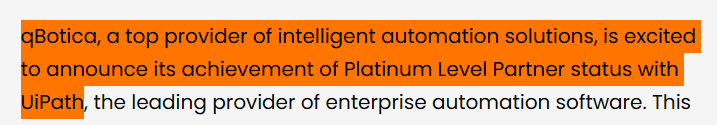

In [223]:
#However, there are different examples where it fails

url="https://qbotica.com/newsroom/qbotica-achieves-platinum-level-partner-status-with-uipath-for-intelligent-automation-solutions/"
retriever = load_and_retrieve_docs(url)
result = rag_chain(question="Who is the CEO of qbotica", retriever=retriever)
display(Markdown(result))

logs: 
{'model': 'gemini-2.5-flash-lite', 'input_tokens': 212, 'output_tokens': 20}


I am sorry, but the provided context does not contain information about the CEO of qBotica.

In [224]:
#This is not true as the website contains information about the CEO of Qbotica.

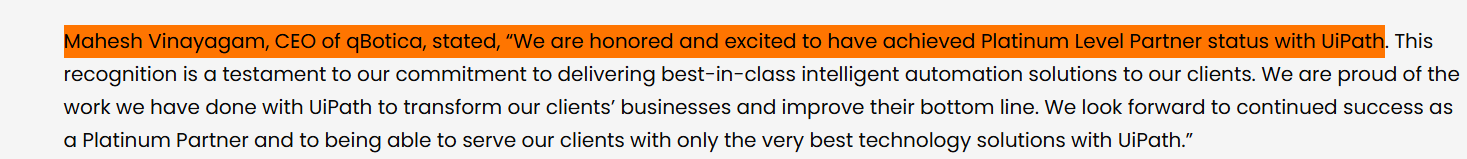

---
### <a id='toc1_5_10_'></a>[**2.6 Few-Shot Prompting Classification:**](#toc0_)

Few-shot prompting is a technique where a Large Language Model (LLM) is given a small number of labeled examples within a prompt to guide its classification. This allows the model to perform a new task with minimal data, avoiding the need for extensive fine-tuning.

In this lab, we will use the Gemini API to perform zero-shot, 1-shot, and 5-shot emotion classification:

*   **Zero-shot:** The model classifies text without any prior examples.
*   **1-shot:** The model is given one example for each emotion before classifying.
*   **5-shot:** The model is given five examples per emotion for better context.

To make our implementation robust and efficient, we are incorporating two key features:

1.  **Structured Output:** We provide the Gemini model with a specific output schema (`Emotions` class). This instructs the model to return *only* a valid emotion label (e.g., `joy`), which makes the output predictable and reliable, minimizing errors.
2.  **API Rate Handling:** The code includes a function to manage the requests-per-minute limit of the Gemini API.

We will test the model's performance on a small sample of 20 texts per emotion to ensure the process runs quickly. If the model provides an invalid response, the code will automatically retry the request until a valid classification is received.

**Prompt Structure:**
`System Instruction -> Task Description -> Examples (if not zero-shot) -> Text to Classify`


<span style="color:green">For the exercises in this section there is no need to re-run the cells, you can use the data that has been saved previously to the corresponding directory.</span>

In [225]:
# Funciton for visualizing confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools

def plot_confusion_matrix(cm, classes, title='Confusion matrix',
                          cmap=sns.cubehelix_palette(as_cmap=True)):
    """
    This function is modified from: 
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    """
    classes.sort()
    tick_marks = np.arange(len(classes))    
    
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels = classes,
           yticklabels = classes,
           title = title,
           xlabel = 'Predicted label',
           ylabel = 'True label')

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")
    ylim_top = len(classes) - 0.5
    plt.ylim([ylim_top, -.5])
    plt.tight_layout()
    plt.show()

In [226]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import enum
import os
from tqdm import tqdm
import json
import time
# Define the emotion labels
emotions = ['anger', 'fear', 'joy', 'sadness']
# Define the model to use for few-shot prompting

# Schema for the output, the type enum can be used to make a pool of options if what we want is to classify our text selecting only one of them
class Emotions(enum.StrEnum):
    ANGER = 'anger'
    FEAR = 'fear'
    JOY = 'joy'
    SADNESS = 'sadness'


# Function to handle the rate limits of gemini models
def handle_rate_limit(request_count, first_request_time, max_calls_per_min):
    current_time = time.time()

    # Initialize timer on the first request of a new window
    if request_count == 0:
        first_request_time = current_time

    request_count += 1

    # If the rate limit is reached
    if request_count > max_calls_per_min:
        elapsed_time = current_time - first_request_time
        if elapsed_time < 60:
            wait_time = 60 - elapsed_time
            print(f"Rate limit of {max_calls_per_min} requests per minute reached. Waiting for {wait_time:.2f} seconds.")
            time.sleep(wait_time)

        # Reset for the new window
        request_count = 1
        first_request_time = time.time()
    
    return request_count, first_request_time, max_calls_per_min

# Function to sample examples per emotion category
def sample_few_shots(df, emotions, num_samples=5):
    few_shot_examples = {}
    for emotion in emotions:
        few_shot_examples[emotion] = df[df['emotion'] == emotion].sample(n=num_samples, random_state=42)
    return few_shot_examples

# Function to build the prompt based on the number of examples (few-shot, 1-shot, zero-shot)
def build_prompt(examples, emotions, num_shots=5):
    classification_instructions = """
You will be given a text extracted from social media and your task is to classify the text into one of the following emotion categories: 
"anger" | "fear" | "joy" | "sadness"
    """
    
    prompt = classification_instructions + "\n\n"
    
    if num_shots > 0:
        prompt += f"Examples: \n"
        for emotion in emotions:
            for _, row in examples[emotion].iterrows():
                prompt += f"Text: {row['text']}\nClass: {emotion}\n\n" #Show the examples in the same format it will be shown for the classification text
                if num_shots == 1:  # If 1-shot, break after the first example for each emotion
                    break
    return prompt

# Function to classify using the LLM with retry for incorrect responses
def classify_with_llm(test_text, prompt_base, system_prompt, classes, schema):
    response = None
    while not response or response not in classes:
        full_prompt = f"{prompt_base}\nClassification:\nText: {test_text}\nClass: " #The classification text will leave the emotion label to be filled in by the LLM
        try:
            result = prompt_gemini(input_prompt = [full_prompt], schema = schema, system_instruction = system_prompt)
            # print(f"result: {result} \n")
            # print(f"type: {type(result)}")
            if not result:
                # In case of giving empty responses with temperature 0.0, we set a higher temperature to seek for different responses
                result = prompt_gemini(input_prompt = [full_prompt], schema = schema, system_instruction = system_prompt, temperature=1.0)

            try:
                # If the result is in the correct format it can be parsed using json
                response = json.load(result)
            except:
                # In case it's not in a json friendly format
                # Deleting characters " and ' in case they appear in our response with the class of the text 
                response = result.replace('"', '')    
                response = response.replace("'", "")  

                
        # except exceptions.ResourceExhausted as e:
        except Exception as e:
            print(f"Waiting to retry... Error: {e}")
            time.sleep(15)
            print(f"test_text: {test_text}")
            return classify_with_llm(test_text, prompt_base, system_prompt, classes, schema) # Retry the request


        if response not in classes:  # Retry if not a valid response
            print(f"Invalid response: {response}. Asking for reclassification.")
    return response

# Main function to run the experiment with the option for zero-shot, 1-shot, or 5-shot prompting
def run_experiment(df_train, df_test, num_test_samples=5, num_shots=5):
    # Sample examples for few-shot prompting based on num_shots
    if num_shots > 0:
        few_shot_examples = sample_few_shots(df_train, emotions, num_samples=num_shots) 
        prompt_base = build_prompt(few_shot_examples, emotions, num_shots=num_shots)
    else:
        prompt_base = build_prompt(None, emotions, num_shots=0)  # Zero-shot has no examples

    # System prompt for our classification model:
    system_prompt = "You are an emotion classification model for text data. Do not give empty responses, classify according to the list of possible classes."

    # Prepare to classify the test set
    results_data = []

    print(prompt_base)
    # Sample 20 examples per emotion for the test set to classify
    test_samples = sample_few_shots(df_test, emotions, num_samples=num_test_samples)

    # Variables to handle rate limit of gemini
    request_count = 0
    max_calls_per_min = 15 # Gemini 2.5 Flash Lite has this maximum set in the documentation
    first_request_time = None

    # Classify 20 test examples (5 from each category) and save predictions
    for emotion in emotions:
        for _, test_row in tqdm(test_samples[emotion].iterrows(), desc=f"Processing samples for emotion: {emotion}...", total=num_test_samples):
            test_text = test_row['text']
            request_count, first_request_time, max_calls_per_min = handle_rate_limit(request_count, first_request_time, max_calls_per_min)  # Check and handle rate limit before each API call
            predicted_emotion = classify_with_llm(test_text = test_text, prompt_base = prompt_base, system_prompt = system_prompt, classes = emotions, schema = Emotions)
            # Append the results data:
            results_data.append({
                    'text': test_text,
                    'true_emotion': emotion,
                    'predicted_emotion': predicted_emotion
                })

    # Create dataframe to save the results data
    results_df = pd.DataFrame(results_data)
    
    # Extract just the true and predicted labels for metrics calculations
    true_labels = results_df['true_emotion']
    predictions = results_df['predicted_emotion']

    output_dir = "./results/llm_classification_results"
    os.makedirs(output_dir, exist_ok=True)
    # Save the results
    filename = f"{output_dir}/results_samples_{num_test_samples}_shots_{num_shots}.csv"
    
    # Save the DataFrame to CSV
    results_df.to_csv(filename, index=False)
    print(f"\nResults saved to {filename}")

    # Calculate accuracy
    accuracy = accuracy_score(true_labels, predictions)
    print(f"Accuracy: {accuracy * 100:.2f}%")
    
    # Classification report
    print(classification_report(y_true=true_labels, y_pred=predictions))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_true=true_labels, y_pred=predictions) 
    my_tags = ['anger', 'fear', 'joy', 'sadness']
    plot_confusion_matrix(cm, classes=my_tags, title=f'Confusion matrix for classification with \n{num_shots}-shot prompting')

**Important: The next part should take around 16 minutes to finish running due to API Rate Limits**

**Note:** You might see an `429 RESOURCE_EXHAUSTED` error when running the following code all at once, this is because the `current API Rate Limit handling cannot reliably find out how many requests we have left per minute` from cell to cell, there is no Gemini feature created for it to get the information from their servers. So, `if you don't want to see the error you can just wait 1 minute` after one cell finished processing. But `even if there is an error showing it is fine`, internally in the code `there is a retry that happens every 15 seconds` until we finish processing our sampled data. `The lab is designed to never reach the total rate limit per day quota.`


You will be given a text extracted from social media and your task is to classify the text into one of the following emotion categories: 
"anger" | "fear" | "joy" | "sadness"
    




Processing samples for emotion: anger...:  65%|██████▌   | 13/20 [00:09<00:05,  1.36it/s]

Error occurred when generating response, error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite\nPlease retry in 46.196479131s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions':

Processing samples for emotion: anger...:  75%|███████▌  | 15/20 [00:56<00:51, 10.25s/it]

Rate limit of 15 requests per minute reached. Waiting for 3.52 seconds.


...

Rate limit of 15 requests per minute reached. Waiting for 49.89 seconds.


Processing samples for emotion: sadness...:  75%|███████▌  | 15/20 [01:02<00:04,  1.00it/s]

Rate limit of 15 requests per minute reached. Waiting for 47.42 seconds.


Processing samples for emotion: sadness...: 100%|██████████| 20/20 [01:54<00:00,  5.74s/it]


Results saved to ./results/llm_classification_results/results_samples_20_shots_0.csv
Accuracy: 56.25%
              precision    recall  f1-score   support

       anger       0.50      0.70      0.58        20
        fear       0.83      0.25      0.38        20
         joy       0.55      0.80      0.65        20
     sadness       0.59      0.50      0.54        20

    accuracy                           0.56        80
   macro avg       0.62      0.56      0.54        80
weighted avg       0.62      0.56      0.54        80



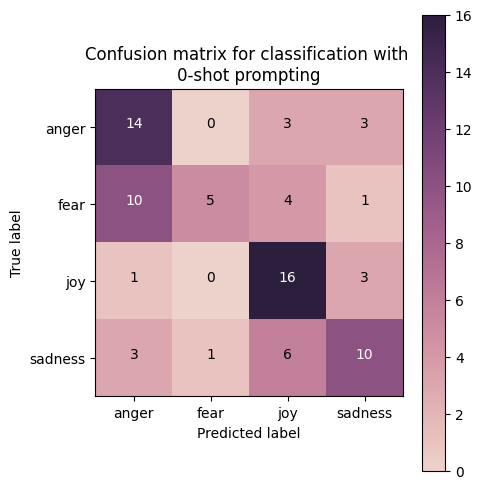

In [227]:
# If you see '429 RESOURCE_EXHAUSTED' errors it's fine, wait until the data gets processed, it will keep retrying until it finishes

# Example of running the experiment with zero-shot prompting
run_experiment(train_df, test_df, num_test_samples=20, num_shots=0)

In [228]:
# print(test_df.to_string())


You will be given a text extracted from social media and your task is to classify the text into one of the following emotion categories: 
"anger" | "fear" | "joy" | "sadness"
    

Examples: 
Text: Prayers &amp; Protection to our brothers and sisters fighting in #Charlotte #rage #against #machines
Class: anger

Text: That goes the #alarm
Class: fear

Text: It has been medically proven that laughter is an effective pain killer.
Class: joy

Text: @JoaquinPutoAmo vas a ir al de the amaity affliction?
Class: sadness




Processing samples for emotion: anger...:  55%|█████▌    | 11/20 [00:07<00:05,  1.54it/s]

Error occurred when generating response, error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite\nPlease retry in 43.501629352s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions':

Processing samples for emotion: anger...:  75%|███████▌  | 15/20 [00:55<00:27,  5.42s/it]

Rate limit of 15 requests per minute reached. Waiting for 4.02 seconds.


...

Rate limit of 15 requests per minute reached. Waiting for 2.47 seconds.


Processing samples for emotion: sadness...:  75%|███████▌  | 15/20 [00:15<00:04,  1.20it/s]

Rate limit of 15 requests per minute reached. Waiting for 47.27 seconds.


Processing samples for emotion: sadness...: 100%|██████████| 20/20 [01:06<00:00,  3.32s/it]


Results saved to ./results/llm_classification_results/results_samples_20_shots_1.csv
Accuracy: 58.75%
              precision    recall  f1-score   support

       anger       0.50      0.55      0.52        20
        fear       1.00      0.35      0.52        20
         joy       0.62      0.75      0.68        20
     sadness       0.52      0.70      0.60        20

    accuracy                           0.59        80
   macro avg       0.66      0.59      0.58        80
weighted avg       0.66      0.59      0.58        80



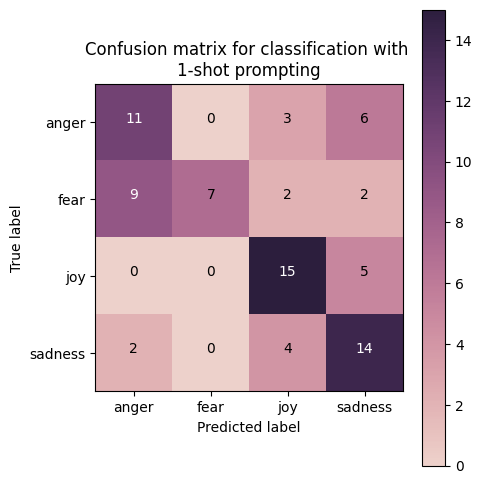

In [229]:
# If you see '429 RESOURCE_EXHAUSTED' errors it's fine, wait until the data gets processed, it will keep retrying until it finishes

# Example of running the experiment with 1-shot prompting
run_experiment(train_df, test_df, num_test_samples=20, num_shots=1)


You will be given a text extracted from social media and your task is to classify the text into one of the following emotion categories: 
"anger" | "fear" | "joy" | "sadness"
    

Examples: 
Text: Prayers &amp; Protection to our brothers and sisters fighting in #Charlotte #rage #against #machines
Class: anger

Text: @ChronAVT ummm, the blog says 'with Simon Stehr faking 7th'...I'll expect an investigation forthwith. This is an 
Class: anger

Text: @voguemagazine, did you not learn from @FreePeople 's viral insult to ballet? Stop trying to wrongfully stick models into pointe shoes 🙄
Class: anger

Text: This all resent #India #Pakistan problem is save #NawazSharif\n@ImranKhanPTI\n@PTIofficial
Class: anger

Text: Be chill af if you want to offend someone.
Class: anger

Text: That goes the #alarm
Class: fear

Text: Omg he kissed her🙈 #shy #w
Class: fear

Text: @GuardianAus @guardian because there is a realistic probability that a clown might be their next president. #clown #uspol #nightm

Processing samples for emotion: anger...:  55%|█████▌    | 11/20 [00:08<00:07,  1.22it/s]

Error occurred when generating response, error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite\nPlease retry in 38.465346295s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions':

Processing samples for emotion: anger...:  75%|███████▌  | 15/20 [00:57<00:27,  5.58s/it]

Rate limit of 15 requests per minute reached. Waiting for 2.47 seconds.


...

Rate limit of 15 requests per minute reached. Waiting for 17.95 seconds.


Processing samples for emotion: sadness...:  75%|███████▌  | 15/20 [00:29<00:04,  1.13it/s]

Rate limit of 15 requests per minute reached. Waiting for 48.01 seconds.


Processing samples for emotion: sadness...: 100%|██████████| 20/20 [01:21<00:00,  4.09s/it]


Results saved to ./results/llm_classification_results/results_samples_20_shots_5.csv
Accuracy: 58.75%
              precision    recall  f1-score   support

       anger       0.55      0.55      0.55        20
        fear       1.00      0.40      0.57        20
         joy       0.58      0.75      0.65        20
     sadness       0.50      0.65      0.57        20

    accuracy                           0.59        80
   macro avg       0.66      0.59      0.58        80
weighted avg       0.66      0.59      0.58        80



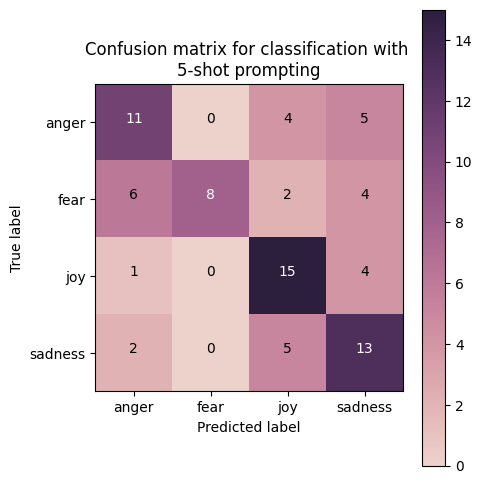

In [230]:
# If you see '429 RESOURCE_EXHAUSTED' errors it's fine, wait until the data gets processed, it will keep retrying until it finishes

# Example of running the experiment with 5-shot prompting
run_experiment(train_df, test_df, num_test_samples=20, num_shots=5)

---
##### <a id='toc1_5_10_1_1_'></a>[**>>> Exercise 6 (Take home):**](#toc0_)

Compare and discuss the overall results of the zero-shot, 1-shot and 5-shot classification.

In [ ]:
# Answer here
# 5-shot prompting yielded the same accuracy result as 1-shot prompting, but both performed better than zero-shot prompting.
# Despite having same accuracy, 5-shot performs better for some class but worse in some others. 
# In fact zero-shot even does better in the anger category than both 1-shot and 5-shot prompting.
# This suggests that providing more examples does not always guarantee better performance across all categories.
# It is possible that the examples provided in the few-shot prompting were not sufficiently diverse enough to represent the class.



---
##### <a id='toc1_5_10_1_2_'></a>[**>>> Exercise 7 (Take home):**](#toc0_)

**Case Study:** Check the results' files inside the `results/llm_classification_results` directory and find cases where the **text classification improves with more examples** (pred emotion is right with examples), **cases where it does not improve** (pred emotion always wrong) and **cases where the classification got worse with more examples** (pred emotion goes from right to wrong with examples). For this you need to load the results with pandas and handle the data using its dataframe functions. Discuss about the findings.

In [232]:
# Answer here
import pandas as pd

#We will first scan the three results files coming from setting different shot values
df_0shot = pd.read_csv(r'D:\kevin\Phase2_Revised\DM2025-Lab2-Exercise_forked\results\llm_classification_results\results_samples_20_shots_0.csv')
df_1shot = pd.read_csv(r'D:\kevin\Phase2_Revised\DM2025-Lab2-Exercise_forked\results\llm_classification_results\results_samples_20_shots_1.csv')
df_5shot = pd.read_csv(r'D:\kevin\Phase2_Revised\DM2025-Lab2-Exercise_forked\results\llm_classification_results\results_samples_20_shots_5.csv')

#See the results of df_0shot
df_0shot 

,text,true_emotion,predicted_emotion
0,You're so thirsty for the chance to disagree w...,anger,anger
1,I think our defense here at USC is playing wel...,anger,joy
2,I think @Sam_Canaday &amp; @KYLEJDOWSON must a...,anger,sadness
3,"@TrevorHMoore @paget_old In Scotland, the righ...",anger,anger
4,@isthataspider @dhodgs i will fight this guy! ...,anger,anger
...,...,...,...
75,Season 3 and Charlie is still a prick! #lost,sadness,anger
76,This shit hurting my heart 😪 that's how seriou...,sadness,sadness
77,SOBRIETY® trying to make being sober fashion...,sadness,joy
78,"Just watched Django Unchained, Other people ma...",sadness,joy


In [233]:
#Calculate the average correct classifcations per emotions and the number of correct and incorrect classifications
print("0-shot classification results:")
df_0shot["correct"] = df_0shot["true_emotion"] == df_0shot["predicted_emotion"]
df_0shot["correct"] = df_0shot["true_emotion"] == df_0shot["predicted_emotion"]
print(df_0shot.groupby("true_emotion")["correct"].value_counts())
print(df_0shot.groupby("true_emotion")["correct"].mean())

0-shot classification results:
true_emotion  correct
anger         True       14
              False       6
fear          False      15
              True        5
joy           True       16
              False       4
sadness       False      10
              True       10
Name: count, dtype: int64
true_emotion
anger      0.70
fear       0.25
joy        0.80
sadness    0.50
Name: correct, dtype: float64


In [234]:
#Calculate the average correct classifcations per emotions and the number of correct and incorrect classifications
print("1-shot classification results:")
df_1shot["correct"] = df_1shot["true_emotion"] == df_1shot["predicted_emotion"]
df_1shot["correct"] = df_1shot["true_emotion"] == df_1shot["predicted_emotion"]
print(df_1shot.groupby("true_emotion")["correct"].value_counts())
print(df_1shot.groupby("true_emotion")["correct"].mean())

1-shot classification results:
true_emotion  correct
anger         True       11
              False       9
fear          False      13
              True        7
joy           True       15
              False       5
sadness       True       14
              False       6
Name: count, dtype: int64
true_emotion
anger      0.55
fear       0.35
joy        0.75
sadness    0.70
Name: correct, dtype: float64


In [235]:
#Calculate the average correct classifcations per emotions and the number of correct and incorrect classifications
print("5-shot classification results:")
df_5shot["correct"] = df_5shot["true_emotion"] == df_5shot["predicted_emotion"]
df_5shotCorrecArr = df_5shot["correct"].values
print(df_5shot.groupby("true_emotion")["correct"].value_counts())
print(df_5shot.groupby("true_emotion")["correct"].mean())

5-shot classification results:
true_emotion  correct
anger         True       11
              False       9
fear          False      12
              True        8
joy           True       15
              False       5
sadness       True       13
              False       7
Name: count, dtype: int64
true_emotion
anger      0.55
fear       0.40
joy        0.75
sadness    0.65
Name: correct, dtype: float64


In [236]:
#Add the correctness classifications from the three prompting methods into a single dataframe for comparison
#Here we can see which particular examples does worse as the number of shots for prompting increases

comparison_df = df_5shot[['text', 'true_emotion']].copy()
comparison_df['0-shot_correct'] = df_0shot['correct']
comparison_df['1-shot_correct'] = df_1shot['correct']
comparison_df['5-shot_correct'] = df_5shot['correct']

print(comparison_df.to_string())

                                                                                                                                                    text true_emotion  0-shot_correct  1-shot_correct  5-shot_correct
0           You're so thirsty for the chance to disagree w/ the left, that you don't even realize when something is an affront to your bigoted platform.        anger            True            True            True
1                      I think our defense here at USC is playing well, we just need to fix a few things on offense and we can win the PAC 12 this year'        anger           False           False           False
2   I think @Sam_Canaday &amp; @KYLEJDOWSON must actually have to be working like me &amp; @dowson_brady because I havent got any snap chat videos today        anger           False           False           False
3                         @TrevorHMoore @paget_old In Scotland, the right-wingers are the most rabid anti-nationalists. Socialists are mostly in

In [237]:
#An example of increasing the number of prompting resulting in worst performance can be seen in example number 41
#"Imagine how sad LA fans are gona be when they get eliminated...Man that's gonna be Nirvana, a religious experience rejoicing in their misery"
#0-shot prompting classifies it correctly, but 1-shot prompting does not

#The same is true for example ID 44

In [238]:
#However for some, such as example ID 9, one-shot and five-shot prompting correctly predicts the emotion while zero-shot prompting does not.

In [239]:
#Going from calculating the accuracy overall to per emotion category, as we increase the number of shots during prompting,
#Most categories improves slightly, except for 'joy' which decreases in accuracy as the number of shots increases.

---
### <a id='toc1_5_11_'></a>[**2.7 Extra LLM Related Materials:**](#toc0_)
So this will be it for the lab, but here are some extra materials if you would like to explore:

- **How to use OpenAI ChatGPT model's API (Not Free API):** [Basics Video](https://www.youtube.com/watch?v=e9P7FLi5Zy8), [Basics GitHub](https://github.com/gkamradt/langchain-tutorials/blob/main/chatapi/ChatAPI%20%2B%20LangChain%20Basics.ipynb), [RAG's Basics Video](https://www.youtube.com/watch?v=9AXP7tCI9PI&t=300s), [RAG's Basics GitHub](https://github.com/techleadhd/chatgpt-retrieval)

- **Advanced topic - QLoRA (Quantized Low-Rank Adapter):** QLoRA is a method used to make fine-tuning large language models more efficient. It works by adding a small, trainable part (LoRA) to a pre-trained model, while keeping the rest of the model frozen. At the same time, it reduces the size of the model’s data using a process called quantization, which makes the model require less memory. This allows you to fine-tune large models without needing as much computational power, making it easier to adapt models for specific tasks. Materials: [Paper GitHub](https://github.com/artidoro/qlora?tab=readme-ov-file), [Llama 3 Application Video](https://www.youtube.com/watch?v=YJNbgusTSF0&t=512s),[Llama 3 Application GitHub](https://github.com/adidror005/youtube-videos/blob/main/LLAMA_3_Fine_Tuning_for_Sequence_Classification_Actual_Video.ipynb)

- **How to Fine-tune and run local LLMs with the `unsloth` library:** [unsloth tutorials](https://docs.unsloth.ai/models/tutorials-how-to-fine-tune-and-run-llms)

- **Google's Agent Development Kit Documentation:** [ADK](https://google.github.io/adk-docs/)

- **Build AI agents with LangGraph:** [LangGraph Documentation](https://langchain-ai.github.io/langgraph/concepts/why-langgraph/)

---